# Import and Settings

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# pd.options.mode.chained_assignment = None

# Load Data

In [3]:
def load_data(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
        print(f"Data has been successfully loaded. Number of rows: {len(df)}, columns: {len(df.columns)}\n")
        return df
    except FileNotFoundError:
        print(f"The {path} file was not found.")
        return None
    except Exception as e:
        print(f"An error occurred when uploading a file: {e}")
        return None

In [4]:
users_df = load_data("users_info.csv")

if users_df is not None:
    print(users_df.head())

Data has been successfully loaded. Number of rows: 76275, columns: 4

  subscription_start_date user_id  gender     geo
0              2024-01-01  user_1    male  tier-1
1              2024-01-01  user_2  female  tier-1
2              2024-01-01  user_3  female  tier-2
3              2024-01-01  user_4    male  tier-2
4              2024-01-01  user_5  female  tier-2


In [5]:
subscriptions_renewals_df = load_data("subscriptions_renewals.csv")

if subscriptions_renewals_df is not None:
    print(subscriptions_renewals_df.head())

Data has been successfully loaded. Number of rows: 149573, columns: 3

    USER_ID RENEWAL_DATE  RENEWAL_NUMBER
0    user_1   2024-01-01               0
1   user_10   2024-01-01               0
2   user_10   2024-02-01               1
3   user_10   2024-03-01               2
4  user_100   2024-01-01               0


# Data quality check

In [6]:
# -------------------------------
# 1. Check number of records
# -------------------------------
print("=" * 60)
print("1. NUMBER OF RECORDS")
print("=" * 60)
print(f"Number of users in users_info: {len(users_df)}")
print(f"Number of events in subscriptions_renewals: {len(subscriptions_renewals_df)}")

# -------------------------------
# 2. Uniqueness of user_id in users_info
# -------------------------------
print("\n" + "=" * 60)
print("2. UNIQUENESS OF user_id IN users_info")
print("=" * 60)
unique_users = users_df['user_id'].nunique()
total_users = len(users_df)
if unique_users == total_users:
    print(f"All user_id are unique: {unique_users} out of {total_users}")
else:
    print(f"Duplicate user_id found: {total_users - unique_users} duplicates")

# -------------------------------
# 3. Users in subscriptions_renewals not present in users_info
# -------------------------------
print("\n" + "=" * 60)
print("3. USERS IN subscriptions_renewals NOT FOUND IN users_info")
print("=" * 60)
missing_users = set(subscriptions_renewals_df['USER_ID']) - set(users_df['user_id'])
if len(missing_users) == 0:
    print("All users from subscriptions_renewals are present in users_info")
else:
    print(f"Found {len(missing_users)} users missing in users_info")

# -------------------------------
# 4. Check for missing values (NaN)
# -------------------------------
print("\n" + "=" * 60)
print("4. MISSING VALUES (NaN) IN DATA")
print("=" * 60)

print("users_info:")
print(users_df.isnull().sum())

print("\nsubscriptions_renewals:")
print(subscriptions_renewals_df.isnull().sum())

# -------------------------------
# 5. Check for duplicates
# -------------------------------
print("\n" + "=" * 60)
print("5. DUPLICATES IN DATA")
print("=" * 60)

print("users_info (full duplicate rows):")
print(len(users_df[users_df.duplicated()]))

print("subscriptions_renewals (full duplicate rows):")
print(len(subscriptions_renewals_df[subscriptions_renewals_df.duplicated()]))

# -------------------------------
# 6. Validate dates
# -------------------------------
print("\n" + "=" * 60)
print("6. DATE VALIDITY")
print("=" * 60)

# Validate subscription_start_date
users_df['subscription_start_date'] = pd.to_datetime(users_df['subscription_start_date'], errors='coerce')
invalid_dates_users = users_df['subscription_start_date'].isnull().sum()
print(f"Invalid dates in subscription_start_date: {invalid_dates_users}")

# Validate RENEWAL_DATE
subscriptions_renewals_df['RENEWAL_DATE'] = pd.to_datetime(subscriptions_renewals_df['RENEWAL_DATE'], errors='coerce')
invalid_dates_renewals = subscriptions_renewals_df['RENEWAL_DATE'].isnull().sum()
print(f"Invalid dates in RENEWAL_DATE: {invalid_dates_renewals}")

# -------------------------------
# 7. Match months of subscription_start_date and RENEWAL_DATE for RENEWAL_NUMBER = 0
# -------------------------------
print("\n" + "=" * 60)
print("7. MONTH MATCH BETWEEN subscription_start_date AND RENEWAL_DATE (RENEWAL_NUMBER = 0)")
print("=" * 60)

# Merge data by user_id
merged = subscriptions_renewals_df.merge(
    users_df[['user_id', 'subscription_start_date']],
    left_on='USER_ID',
    right_on='user_id',
    how='left'
)

# Filter only RENEWAL_NUMBER = 0
first_purchases = merged[merged['RENEWAL_NUMBER'] == 0].copy()

# Compare months
first_purchases['start_month'] = first_purchases['subscription_start_date'].dt.to_period('M')
first_purchases['renewal_month'] = first_purchases['RENEWAL_DATE'].dt.to_period('M')

mismatch = first_purchases[first_purchases['start_month'] != first_purchases['renewal_month']]

if len(mismatch) == 0:
    print("All first purchases (RENEWAL_NUMBER=0) match the month of subscription_start_date")
else:
    print(f"Found {len(mismatch)} records where subscription_start_date month != RENEWAL_DATE month")

# -------------------------------
# 8. Missing RENEWAL_NUMBER within user history
# -------------------------------
print("\n" + "=" * 60)
print("8. MISSING RENEWAL_NUMBER WITHIN USER HISTORY")
print("=" * 60)

# Sort by USER_ID and RENEWAL_DATE
subscriptions_renewals_df_sorted = subscriptions_renewals_df.sort_values(['USER_ID', 'RENEWAL_DATE']).copy()

# Check for gaps in renewal numbers (e.g., 0, 1, 3 — missing 2)
def has_gap(renewal_series):
    valid_renewals = pd.to_numeric(renewal_series, errors='coerce').dropna().astype(int).sort_values().tolist()
    if len(valid_renewals) == 0:
        return False
    expected = list(range(len(valid_renewals)))
    return expected != valid_renewals

gaps = subscriptions_renewals_df_sorted.groupby('USER_ID')['RENEWAL_NUMBER'].apply(has_gap)
gaps_users = gaps[gaps].index.tolist()

if len(gaps_users) == 0:
    print("No missing RENEWAL_NUMBER within user histories")
else:
    print(f"Found {len(gaps_users)} users with missing RENEWAL_NUMBER")

# -------------------------------
# 9. Users with multiple events for the same RENEWAL_NUMBER
# -------------------------------
print("\n" + "=" * 60)
print("9. USERS WITH MULTIPLE EVENTS FOR THE SAME RENEWAL_NUMBER")
print("=" * 60)

duplicates_by_renewal = subscriptions_renewals_df.groupby(['USER_ID', 'RENEWAL_NUMBER']).size()
duplicates_by_renewal = duplicates_by_renewal[duplicates_by_renewal > 1]

if len(duplicates_by_renewal) == 0:
    print("All users have unique RENEWAL_NUMBER")
else:
    print(f"Found {len(duplicates_by_renewal)} (USER_ID, RENEWAL_NUMBER) combinations with multiple events")
    # print(duplicates_by_renewal.head(10))

# -------------------------------
# 10. Maximum observation depth per subscription
# -------------------------------
print("\n" + "=" * 60)
print("10. MAXIMUM OBSERVATION DEPTH PER SUBSCRIPTION")
print("=" * 60)

max_renewal = subscriptions_renewals_df['RENEWAL_NUMBER'].max()
print(f"Maximum RENEWAL_NUMBER: {max_renewal}")
print(f"Average RENEWAL_NUMBER: {subscriptions_renewals_df['RENEWAL_NUMBER'].mean():.2f}")

# Distribution by RENEWAL_NUMBER
print("\nDistribution by RENEWAL_NUMBER:")
print(subscriptions_renewals_df['RENEWAL_NUMBER'].value_counts().sort_index())

1. NUMBER OF RECORDS
Number of users in users_info: 76275
Number of events in subscriptions_renewals: 149573

2. UNIQUENESS OF user_id IN users_info
All user_id are unique: 76275 out of 76275

3. USERS IN subscriptions_renewals NOT FOUND IN users_info
All users from subscriptions_renewals are present in users_info

4. MISSING VALUES (NaN) IN DATA
users_info:
subscription_start_date    0
user_id                    0
gender                     0
geo                        0
dtype: int64

subscriptions_renewals:
USER_ID           0
RENEWAL_DATE      0
RENEWAL_NUMBER    0
dtype: int64

5. DUPLICATES IN DATA
users_info (full duplicate rows):
0
subscriptions_renewals (full duplicate rows):
0

6. DATE VALIDITY
Invalid dates in subscription_start_date: 0
Invalid dates in RENEWAL_DATE: 0

7. MONTH MATCH BETWEEN subscription_start_date AND RENEWAL_DATE (RENEWAL_NUMBER = 0)
All first purchases (RENEWAL_NUMBER=0) match the month of subscription_start_date

8. MISSING RENEWAL_NUMBER WITHIN USER HIS

# Data Transformation

In [7]:
# Create a "template" for each user across 12 months
# Generate all lifecycle_month from 0 to 11 for each user
user_months = []
for _, user_row in users_df.iterrows():
    user_id = user_row['user_id']
    cohort_month = user_row['subscription_start_date'].to_period('M')
    gender = user_row['gender']
    geo = user_row['geo']
    for lifecycle_month in range(12):  # 0 до 11
        user_months.append({
            'user_id': user_id,
            'cohort_month': cohort_month,
            'lifecycle_month': lifecycle_month,
            'gender': gender,
            'geo': geo,
            'renewed': 0,  # default: not renewed
            'revenue': 0.0
        })

# Create DataFrame
panel_df = pd.DataFrame(user_months)

# Merge with renewal data
subscriptions_renewals_df['RENEWAL_NUMBER'] = pd.to_numeric(subscriptions_renewals_df['RENEWAL_NUMBER'], errors='coerce').astype('Int64')

# Keep only events where RENEWAL_NUMBER <= 11 (within horizon)
valid_renewals = subscriptions_renewals_df[
    (subscriptions_renewals_df['RENEWAL_NUMBER'].notna()) &
    (subscriptions_renewals_df['RENEWAL_NUMBER'] <= 11)
].copy()

# Merge by user_id and RENEWAL_NUMBER = lifecycle_month
merged = panel_df.merge(
    valid_renewals[['USER_ID', 'RENEWAL_NUMBER']].rename(columns={'USER_ID': 'user_id', 'RENEWAL_NUMBER': 'lifecycle_month'}),
    on=['user_id', 'lifecycle_month'],
    how='left',
    indicator=True
)

# Mark where renewal event occurred
panel_df['renewed'] = merged['_merge'] == 'both'
panel_df['revenue'] = panel_df['renewed'] * 29.99

# Remove temporary columns
panel_df = panel_df.drop(columns=['renewed'], errors='ignore')
panel_df['renewed'] = merged['_merge'] == 'both'
panel_df['revenue'] = panel_df['renewed'] * 29.99

# Remove temporary _merge column
panel_df = panel_df.drop(columns=['_merge'], errors='ignore')

# Sort
panel_df = panel_df.sort_values(['user_id', 'lifecycle_month']).reset_index(drop=True)

# Display result
print("User-month panel analytics view created")
print(f"Size: {len(panel_df)} rows, {len(panel_df.columns)} columns")
print("\nFirst 12 rows:")
print(panel_df.head(12))

User-month panel analytics view created
Size: 915300 rows, 7 columns

First 12 rows:
   user_id cohort_month  lifecycle_month gender     geo  revenue  renewed
0   user_1      2024-01                0   male  tier-1    29.99     True
1   user_1      2024-01                1   male  tier-1     0.00    False
2   user_1      2024-01                2   male  tier-1     0.00    False
3   user_1      2024-01                3   male  tier-1     0.00    False
4   user_1      2024-01                4   male  tier-1     0.00    False
5   user_1      2024-01                5   male  tier-1     0.00    False
6   user_1      2024-01                6   male  tier-1     0.00    False
7   user_1      2024-01                7   male  tier-1     0.00    False
8   user_1      2024-01                8   male  tier-1     0.00    False
9   user_1      2024-01                9   male  tier-1     0.00    False
10  user_1      2024-01               10   male  tier-1     0.00    False
11  user_1      2024-01    

# Exploratory analysis

1. NUMBER OF USERS BY COHORTS
cohort_month  user_count  cumulative
     2024-01       10624       10624
     2024-02        9349       19973
     2024-03        7064       27037
     2024-04        2390       29427
     2024-05        5152       34579
     2024-06        8074       42653
     2024-07        4727       47380
     2024-08        5099       52479
     2024-09        6640       59119
     2024-10        2549       61668
     2024-11        3612       65280
     2024-12       10995       76275


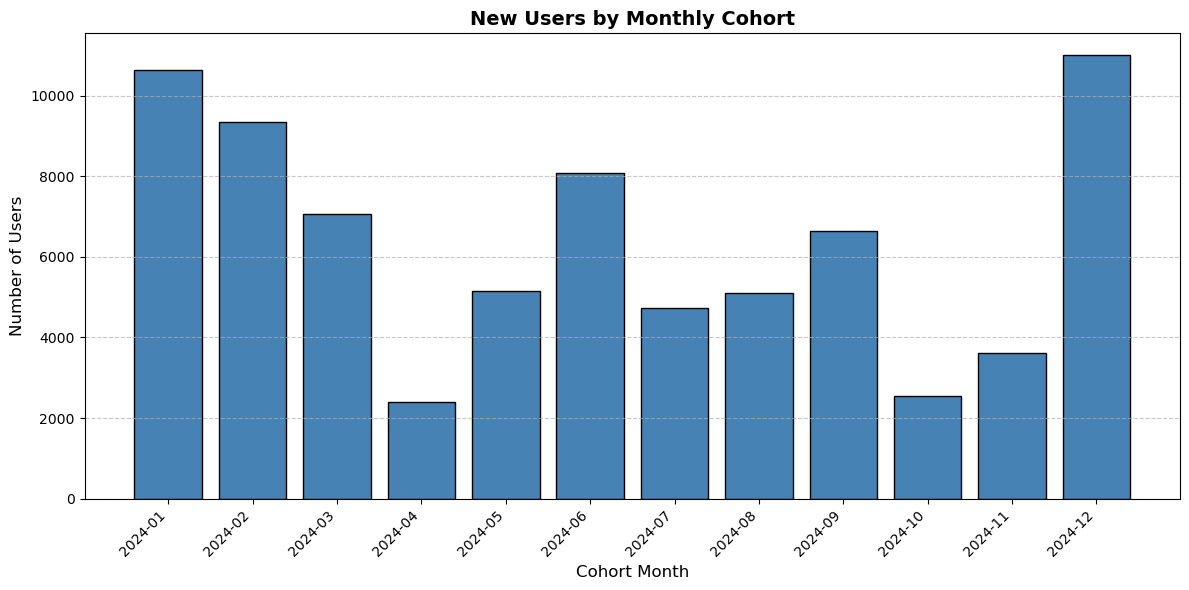

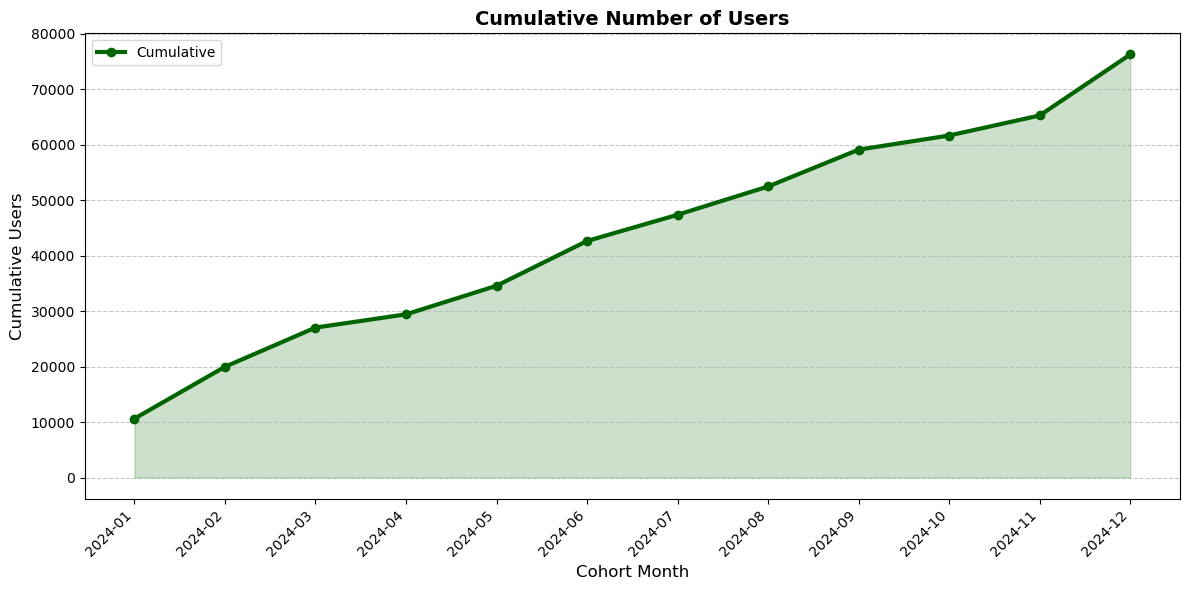


2. NUMBER OF RENEWAL EVENTS PER USER
Average: 1.96
Average (excluding first purchase): 2.61
Median: 1.0
Median (excluding first purchase): 1.0
Maximum: 12
Maximum (excluding first purchase): 11

Distribution (renewals count vs number of users):
renewal_count
1     48272
2     14078
3      4901
4      2468
5      1973
6      1229
7       782
8       773
9       452
10      253
11      387
12      707

3. DISTRIBUTION BY GENDER
gender  user_count    pct
female       49324 64.70%
  male       26951 35.30%

4. DISTRIBUTION BY GEO
   geo  user_count    pct
tier-1       44472 58.30%
tier-2       31803 41.70%

5. GENDER AND GEO CROSS-TABULATION
geo     tier-1  tier-2
gender                
female   29326   19998
male     15146   11805


In [8]:
# -------------------------------
# 1. Number of users by cohorts
# -------------------------------
print("=" * 60)
print("1. NUMBER OF USERS BY COHORTS")
print("=" * 60)
cohort_counts = panel_df.groupby('cohort_month')['user_id'].nunique().reset_index(name='user_count')
cohort_counts = cohort_counts.sort_values('cohort_month').reset_index(drop=True)
cohort_counts['cumulative'] = cohort_counts['user_count'].cumsum()
print(cohort_counts.to_string(index=False))

# -------------------------------
# Table: User acquisition dynamics by cohort and cumulative
# -------------------------------
plt.figure(figsize=(12, 6))
plt.bar(cohort_counts['cohort_month'].astype(str), cohort_counts['user_count'], color='steelblue', edgecolor='black')
plt.title("New Users by Monthly Cohort", fontsize=14, fontweight='bold')
plt.xlabel("Cohort Month", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(cohort_counts['cohort_month'].astype(str), cohort_counts['cumulative'],
         marker='o', linewidth=3, color='darkgreen', label='Cumulative')
plt.fill_between(cohort_counts['cohort_month'].astype(str), cohort_counts['cumulative'],
                 alpha=0.2, color='darkgreen')
plt.title("Cumulative Number of Users", fontsize=14, fontweight='bold')
plt.xlabel("Cohort Month", fontsize=12)
plt.ylabel("Cumulative Users", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# 2. Number of renewal events per user
# -------------------------------
print("\n" + "=" * 60)
print("2. NUMBER OF RENEWAL EVENTS PER USER")
print("=" * 60)

renewals_per_user = panel_df[panel_df['renewed']].groupby('user_id').size().reset_index(name='renewal_count')
renewals_per_user_fact = panel_df[(panel_df['renewed']) & (panel_df['lifecycle_month'] >= 1)].groupby('user_id').size().reset_index(name='renewal_count')

print(f"Average: {renewals_per_user['renewal_count'].mean():.2f}")
print(f"Average (excluding first purchase): {renewals_per_user_fact['renewal_count'].mean():.2f}")

print(f"Median: {renewals_per_user['renewal_count'].median()}")
print(f"Median (excluding first purchase): {renewals_per_user_fact['renewal_count'].median()}")

print(f"Maximum: {renewals_per_user['renewal_count'].max()}")
print(f"Maximum (excluding first purchase): {renewals_per_user_fact['renewal_count'].max()}")

print(f"\nDistribution (renewals count vs number of users):")
print(renewals_per_user['renewal_count'].value_counts().sort_index().to_string())

# -------------------------------
# 3. Distribution by gender
# -------------------------------
print("\n" + "=" * 60)
print("3. DISTRIBUTION BY GENDER")
print("=" * 60)
gender_dist = panel_df.groupby('gender')['user_id'].nunique().reset_index(name='user_count')
gender_dist['pct'] = (gender_dist['user_count'] / gender_dist['user_count'].sum() * 100).round(1)
print(gender_dist.to_string(index=False, formatters={'pct': lambda x: f"{x:.2f}%"}))

# -------------------------------
# 4. Распределение по geo
# -------------------------------
print("\n" + "=" * 60)
print("4. DISTRIBUTION BY GEO")
print("=" * 60)
geo_dist = panel_df.groupby('geo')['user_id'].nunique().reset_index(name='user_count')
geo_dist['pct'] = (geo_dist['user_count'] / geo_dist['user_count'].sum() * 100).round(1)
print(geo_dist.to_string(index=False, formatters={'pct': lambda x: f"{x:.2f}%"}))

# -------------------------------
# 5. Cross-tabulation of gender and geo
# -------------------------------
print("\n" + "=" * 60)
print("5. GENDER AND GEO CROSS-TABULATION")
print("=" * 60)
gender_geo_cross = panel_df.groupby(['gender', 'geo'])['user_id'].nunique().unstack(fill_value=0)
print(gender_geo_cross)

# Cohort Retention Analysis

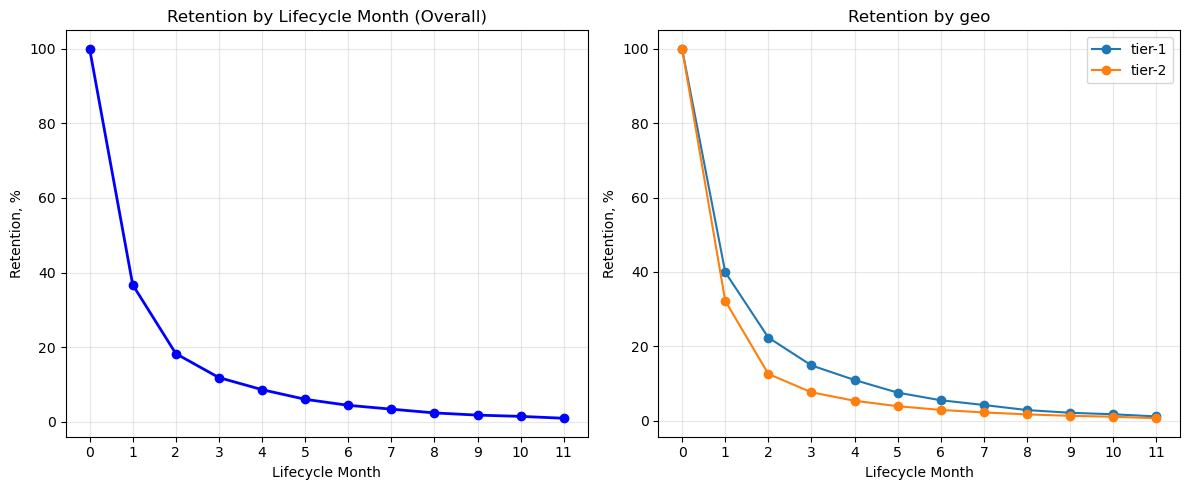

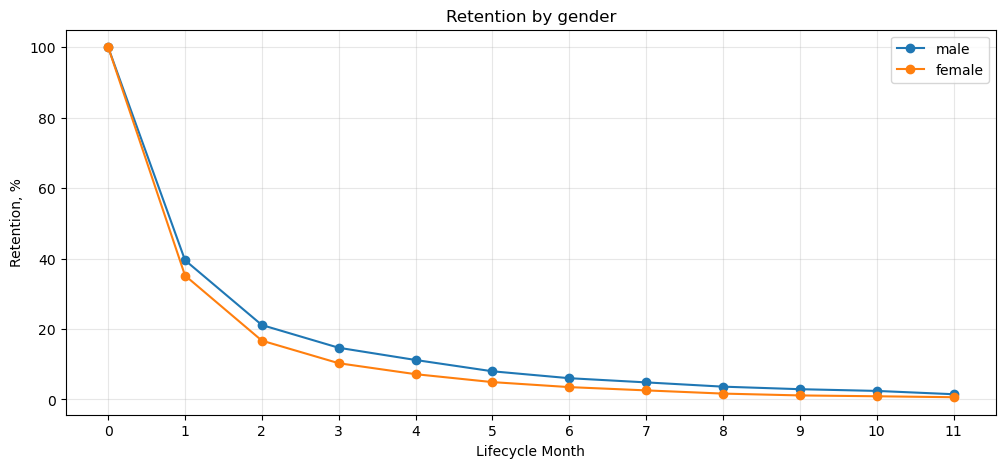

In [9]:
# -------------------------------
# 1. Retention curve by lifecycle_month (overall)
# -------------------------------
plt.figure(figsize=(12, 5))

# Group by lifecycle_month to calculate retention
retention_overall = panel_df.groupby('lifecycle_month')['renewed'].agg(
    total_users='count',
    retained_users='sum'
).reset_index()

retention_overall['retention_pct'] = (retention_overall['retained_users'] / retention_overall['total_users'] * 100).round(2)

plt.subplot(1, 2, 1)
plt.plot(retention_overall['lifecycle_month'], retention_overall['retention_pct'],
         marker='o', linewidth=2, color='blue')
plt.title('Retention by Lifecycle Month (Overall)')
plt.xlabel('Lifecycle Month')
plt.ylabel('Retention, %')
plt.grid(True, alpha=0.3)
plt.xticks(range(12))

# -------------------------------
# 2. Retention curve by geo
# -------------------------------
plt.subplot(1, 2, 2)
for tier in panel_df['geo'].unique():
    data = panel_df[panel_df['geo'] == tier].groupby('lifecycle_month')['renewed'].agg(
        total_users='count',
        retained_users='sum'
    ).reset_index()
    data['retention_pct'] = (data['retained_users'] / data['total_users'] * 100).round(2)
    plt.plot(data['lifecycle_month'], data['retention_pct'], marker='o', label=tier)

plt.title('Retention by geo')
plt.xlabel('Lifecycle Month')
plt.ylabel('Retention, %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(12))

plt.tight_layout()
plt.show()

# -------------------------------
# 3. Retention curve by gender
# -------------------------------
plt.figure(figsize=(12, 5))
for gender in panel_df['gender'].unique():
    data = panel_df[panel_df['gender'] == gender].groupby('lifecycle_month')['renewed'].agg(
        total_users='count',
        retained_users='sum'
    ).reset_index()
    data['retention_pct'] = (data['retained_users'] / data['total_users'] * 100).round(2)
    plt.plot(data['lifecycle_month'], data['retention_pct'], marker='o', label=gender)

plt.title('Retention by gender')
plt.xlabel('Lifecycle Month')
plt.ylabel('Retention, %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(12))
plt.show()


BUILDING RETENTION MATRIX


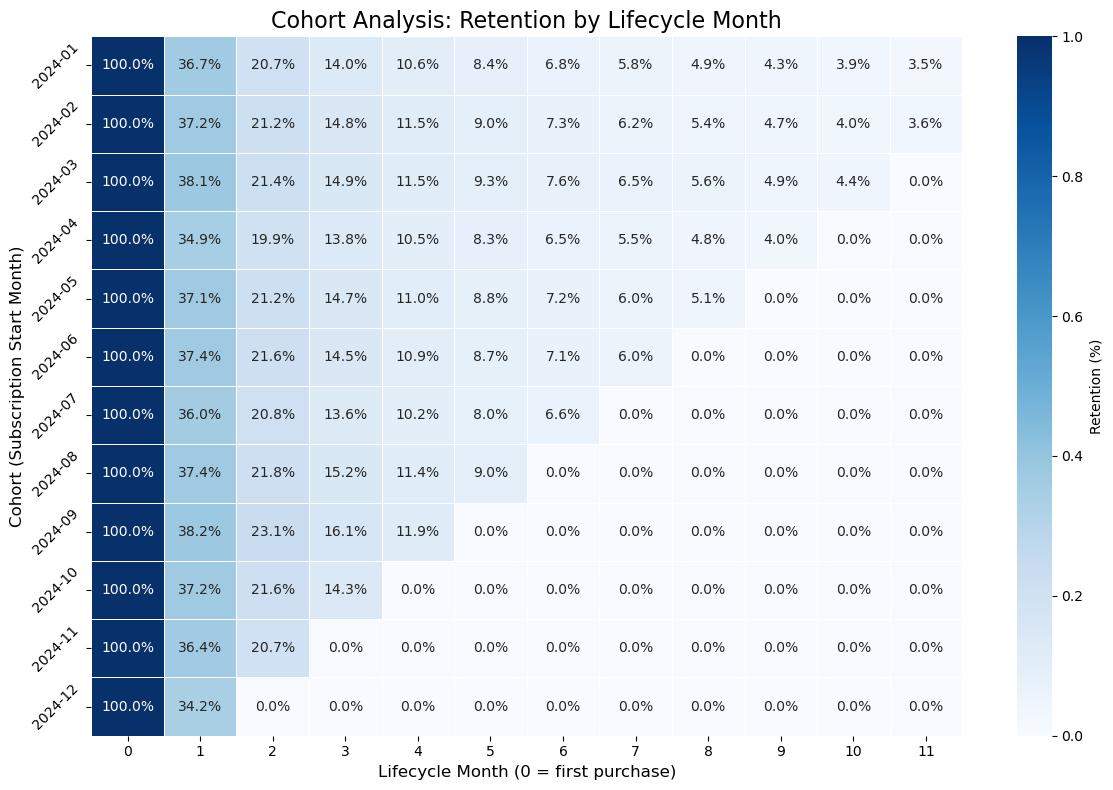

In [10]:
# -------------------------------
# BUILDING RETENTION MATRIX
# -------------------------------
print("\n" + "=" * 60)
print("BUILDING RETENTION MATRIX")
print("=" * 60)

# Group by cohort and lifecycle month
cohort_retention = panel_df.groupby(['cohort_month', 'lifecycle_month']).agg(
    total_users=('user_id', 'nunique'),
    renewed_users=('renewed', 'sum')
).reset_index()

# Add retention rate
cohort_retention['retention_rate'] = cohort_retention['renewed_users'] / cohort_retention['total_users']

# Pivot into matrix: rows = cohorts, columns = lifecycle_month
retention_pivot = cohort_retention.pivot_table(
    index='cohort_month',
    columns='lifecycle_month',
    values='retention_rate',
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Retention (%)'}
)

plt.title('Cohort Analysis: Retention by Lifecycle Month', fontsize=16)
plt.xlabel('Lifecycle Month (0 = first purchase)', fontsize=12)
plt.ylabel('Cohort (Subscription Start Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# LTV Analysis

CUMULATIVE LTV BY COHORTS AND LIFECYCLE MONTHS
              month_0  month_1  month_2  month_3  month_4  month_5  month_6  \
cohort_month                                                                  
2024-01         29.99    40.98    47.18    51.37    54.54    57.06    59.10   
2024-02         29.99    41.16    47.51    51.94    55.39    58.10    60.29   
2024-03         29.99    41.43    47.86    52.33    55.76    58.55    60.83   
2024-04         29.99    40.47    46.44    50.59    53.73    56.22    58.16   
2024-05         29.99    41.13    47.48    51.88    55.17    57.81    59.98   
2024-06         29.99    41.21    47.67    52.02    55.29    57.90    60.03   
2024-07         29.99    40.78    47.01    51.10    54.15    56.53    58.50   
2024-08         29.99    41.20    47.73    52.29    55.70    58.40    58.40   
2024-09         29.99    41.44    48.37    53.18    56.76    56.76    56.76   
2024-10         29.99    41.14    47.63    51.91    51.91    51.91    51.91   
2024-

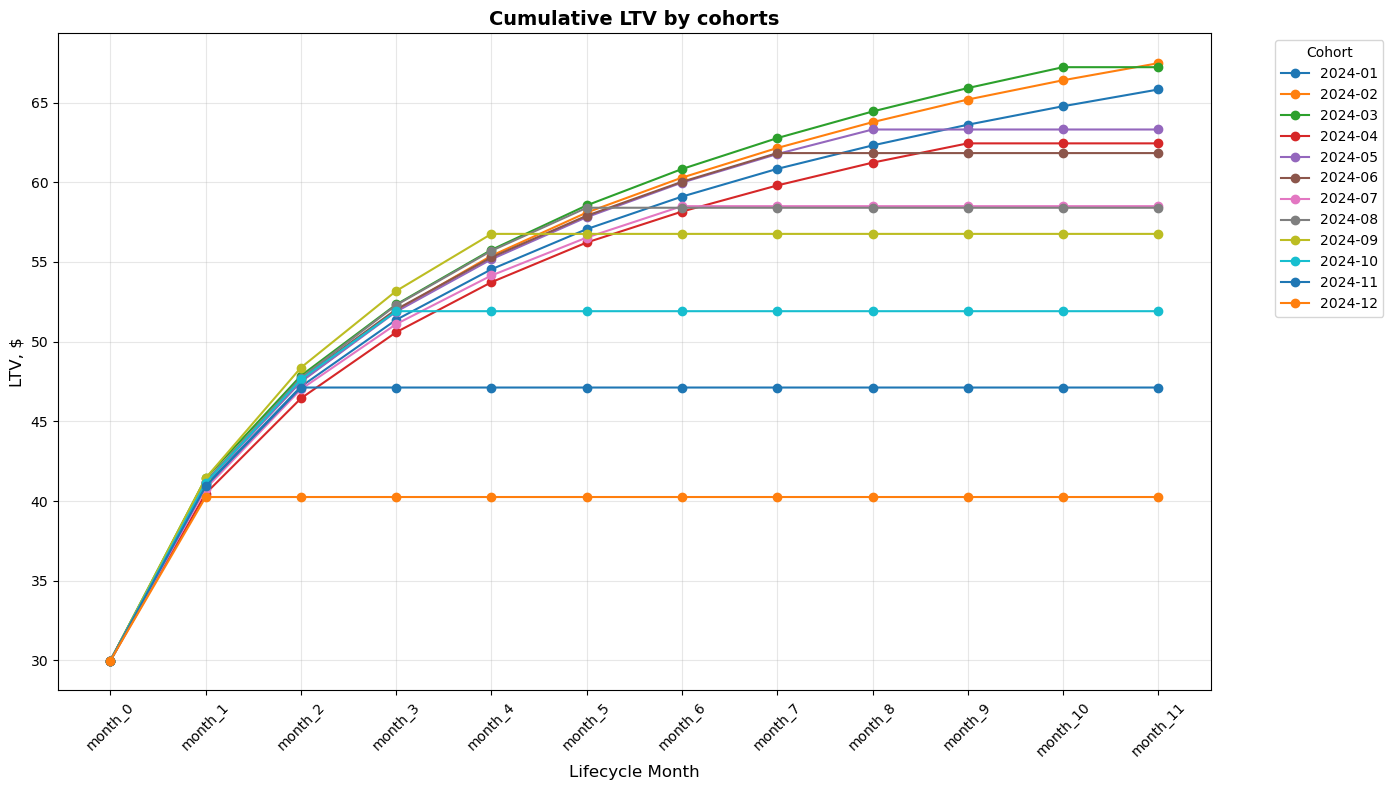


AVERAGE LTV AT THE END OF HORIZON (MONTH_11)
 cohort ltv_month_11
2024-01       $65.82
2024-02       $67.47
2024-03       $67.22
2024-04       $62.44
2024-05       $63.31
2024-06       $61.83
2024-07       $58.50
2024-08       $58.40
2024-09       $56.76
2024-10       $51.91
2024-11       $47.12
2024-12       $40.25

Average LTV at month_11 across all cohorts: $58.42


In [11]:
# -------------------------------
# Cumulative LTV curve by cohorts
# -------------------------------
print("=" * 60)
print("CUMULATIVE LTV BY COHORTS AND LIFECYCLE MONTHS")
print("=" * 60)

revenue_by_cohort_month = panel_df.groupby(['cohort_month', 'lifecycle_month'])['revenue'].sum().reset_index()
cohort_user_counts = panel_df.groupby('cohort_month')['user_id'].nunique().reset_index(name='user_count')
revenue_by_cohort_month = revenue_by_cohort_month.merge(cohort_user_counts, on='cohort_month', how='left')
revenue_by_cohort_month['arpu'] = revenue_by_cohort_month['revenue'] / revenue_by_cohort_month['user_count']
revenue_by_cohort_month['cumulative_arpu'] = revenue_by_cohort_month.groupby('cohort_month')['arpu'].cumsum()

arpu_pivot = revenue_by_cohort_month.pivot_table(
    index='cohort_month',
    columns='lifecycle_month',
    values='cumulative_arpu'
).fillna(0).round(2)

arpu_pivot.columns = [f'month_{i}' for i in arpu_pivot.columns]
print(arpu_pivot)

plt.figure(figsize=(14, 8))
for cohort in arpu_pivot.index:
    plt.plot(arpu_pivot.columns, arpu_pivot.loc[cohort], marker='o', label=str(cohort))

plt.title('Cumulative LTV by сohorts', fontsize=14, fontweight='bold')
plt.xlabel('Lifecycle Month', fontsize=12)
plt.ylabel('LTV, $', fontsize=12)
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# Table: Average LTV per cohort at month_11
# -------------------------------
print("\n" + "=" * 60)
print("AVERAGE LTV AT THE END OF HORIZON (MONTH_11)")
print("=" * 60)

ltv_by_cohort = arpu_pivot['month_11'].reset_index().rename(columns={'cohort_month': 'cohort', 'month_11': 'ltv_month_11'})
print(ltv_by_cohort.to_string(index=False, formatters={'ltv_month_11': lambda x: f"${x:.2f}"}))

# Средний LTV по всем когортам
avg_ltv = ltv_by_cohort['ltv_month_11'].mean()
print(f"\nAverage LTV at month_11 across all cohorts: ${avg_ltv:.2f}")

In [12]:
# ============================================================
# PREPARE DATA FOR DISCRETE-TIME RETENTION MODEL
# ============================================================
print("=" * 60)
print("PREPARE DATA FOR DISCRETE-TIME RETENTION MODEL")
print("=" * 60)

# -------------------------------
# Constants
# -------------------------------

MONTHLY_PRICE = 29.99
FORECAST_HORIZON_MONTHS = 12
RANDOM_STATE = 42
JAN_2024 = pd.Period('2024-01', freq='M')
DEC_2024 = pd.Period('2024-12', freq='M')

# -------------------------------
# Create a separate dataframe for modeling,
# to avoid modifying the original panel_df
# -------------------------------

model_panel_df = panel_df.copy()

# Just in case, convert cohort_month to Period[M]
if not isinstance(model_panel_df['cohort_month'].iloc[0], pd.Period):
    model_panel_df['cohort_month'] = pd.to_datetime(model_panel_df['cohort_month']).dt.to_period('M')

# Convert renewed to int
model_panel_df['renewed'] = model_panel_df['renewed'].astype(int)

# -------------------------------
# Determine the maximum observed month in the data
# -------------------------------

subscriptions_renewals_df['RENEWAL_DATE'] = pd.to_datetime(
    subscriptions_renewals_df['RENEWAL_DATE'],
    errors='coerce'
)

max_observed_month = subscriptions_renewals_df['RENEWAL_DATE'].dt.to_period('M').max()
print(f"Maximum observed month in renewals: {max_observed_month}")

# -------------------------------
# Calculate calendar month for each lifecycle_month
# -------------------------------

model_panel_df['expected_renewal_month'] = model_panel_df.apply(
    lambda row: row['cohort_month'] + int(row['lifecycle_month']),
    axis=1
)

# -------------------------------
# Important note:
# If expected_renewal_month > max_observed_month,
# we could not yet have observed this renewal
# Therefore, absence of renewed != churn
# -------------------------------

model_panel_df['is_observable'] = (
    model_panel_df['expected_renewal_month'] <= max_observed_month
).astype(int)

print("\nObservability check:")
print(model_panel_df.groupby('lifecycle_month')['is_observable'].mean().reset_index(name='observable_share'))

print("\nmodel_panel_df shape:")
print(model_panel_df.shape)

display(model_panel_df.head(12))

PREPARE DATA FOR DISCRETE-TIME RETENTION MODEL
Maximum observed month in renewals: 2025-01

Observability check:
    lifecycle_month  observable_share
0                 0          1.000000
1                 1          1.000000
2                 2          0.855851
3                 3          0.808496
4                 4          0.775077
5                 5          0.688024
6                 6          0.621173
7                 7          0.559200
8                 8          0.453346
9                 9          0.385801
10               10          0.354467
11               11          0.261855

model_panel_df shape:
(915300, 9)


,user_id,cohort_month,lifecycle_month,gender,geo,revenue,renewed,expected_renewal_month,is_observable
0,user_1,2024-01,0,male,tier-1,29.99,1,2024-01,1
1,user_1,2024-01,1,male,tier-1,0.00,0,2024-02,1
2,user_1,2024-01,2,male,tier-1,0.00,0,2024-03,1
3,user_1,2024-01,3,male,tier-1,0.00,0,2024-04,1
4,user_1,2024-01,4,male,tier-1,0.00,0,2024-05,1
5,user_1,2024-01,5,male,tier-1,0.00,0,2024-06,1
6,user_1,2024-01,6,male,tier-1,0.00,0,2024-07,1
7,user_1,2024-01,7,male,tier-1,0.00,0,2024-08,1
8,user_1,2024-01,8,male,tier-1,0.00,0,2024-09,1
9,user_1,2024-01,9,male,tier-1,0.00,0,2024-10,1


CHECK CENSORING BY COHORT
Cohort observability:


,cohort_month,users,max_observable_lifecycle_month,observable_rows,total_rows,observable_share
0,2024-01,10624,11,127488,127488,1.000
1,2024-02,9349,11,112188,112188,1.000
2,2024-03,7064,10,77704,84768,0.917
3,2024-04,2390,9,23900,28680,0.833
4,2024-05,5152,8,46368,61824,0.750
5,2024-06,8074,7,64592,96888,0.667
6,2024-07,4727,6,33089,56724,0.583
7,2024-08,5099,5,30594,61188,0.500
8,2024-09,6640,4,33200,79680,0.417
9,2024-10,2549,3,10196,30588,0.333


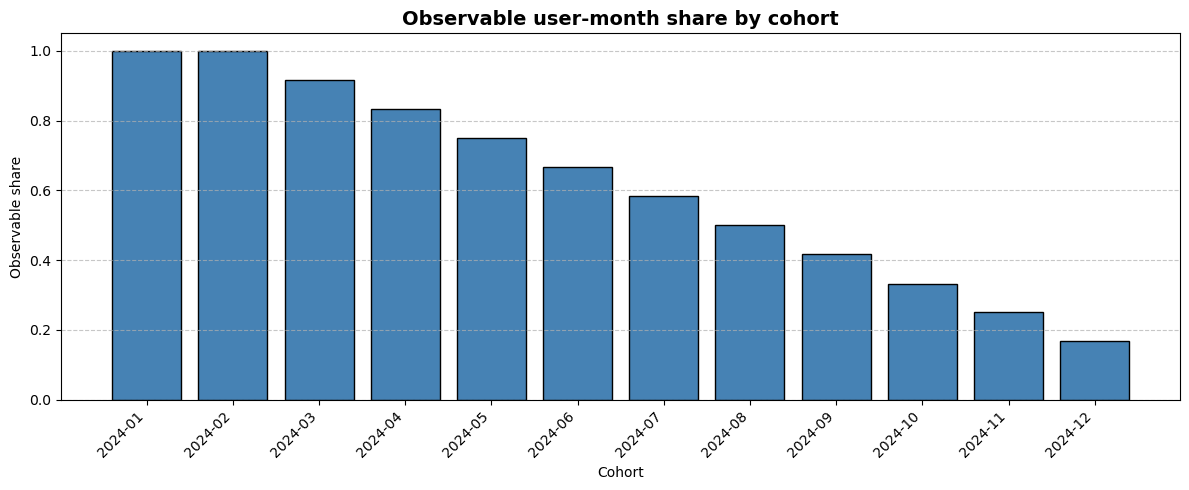

In [13]:
# ============================================================
# CHECK CENSORING BY COHORT
# ============================================================
print("=" * 60)
print("CHECK CENSORING BY COHORT")
print("=" * 60)

# -------------------------------
# How many months are actually observable for each cohort
# -------------------------------
cohort_observability = model_panel_df.groupby('cohort_month').agg(
    users=('user_id', 'nunique'),
    max_observable_lifecycle_month=('lifecycle_month', lambda x: model_panel_df.loc[x.index][model_panel_df.loc[x.index, 'is_observable'] == 1]['lifecycle_month'].max()),
    observable_rows=('is_observable', 'sum'),
    total_rows=('is_observable', 'count')
).reset_index()

cohort_observability['observable_share'] = (
    cohort_observability['observable_rows'] / cohort_observability['total_rows']
).round(3)

print("Cohort observability:")
display(cohort_observability)

plt.figure(figsize=(12, 5))
plt.bar(
    cohort_observability['cohort_month'].astype(str),
    cohort_observability['observable_share'],
    color='steelblue',
    edgecolor='black'
)
plt.title('Observable user-month share by cohort', fontsize=14, fontweight='bold')
plt.xlabel('Cohort')
plt.ylabel('Observable share')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# REATE FEATURES FOR DISCRETE-TIME MODEL
# ============================================================
print("=" * 60)
print("CREATE FEATURES FOR DISCRETE-TIME MODEL")
print("=" * 60)

# -------------------------------
# Train model only on observable rows
# and only for lifecycle_month >= 1
#
# lifecycle_month = 0 — initial purchase
# It has already occurred for all users in users_info,
# so it does not need to be predicted
# -------------------------------
retention_model_df = model_panel_df[
    (model_panel_df['is_observable'] == 1) &
    (model_panel_df['lifecycle_month'] >= 1)
].copy()

# -------------------------------
# Basic features
# -------------------------------
retention_model_df['cohort_month_num'] = retention_model_df['cohort_month'].dt.month
retention_model_df['expected_calendar_month_num'] = retention_model_df['expected_renewal_month'].dt.month

# Dummy variables in style of previous code
retention_model_df['gender_male'] = (retention_model_df['gender'] == 'male').astype(int)
retention_model_df['gender_female'] = (retention_model_df['gender'] == 'female').astype(int)

retention_model_df['geo_tier1'] = (retention_model_df['geo'] == 'tier-1').astype(int)
retention_model_df['geo_tier2'] = (retention_model_df['geo'] == 'tier-2').astype(int)

# -------------------------------
# Dummy variables for lifecycle_month
# This allows the model to have a separate baseline retention
# for each month of subscription life
# -------------------------------
for month in range(1, FORECAST_HORIZON_MONTHS):
    retention_model_df[f'lifecycle_month_{month}'] = (
        retention_model_df['lifecycle_month'] == month
    ).astype(int)

# -------------------------------
# Cohort seasonality: month of subscription start
# -------------------------------
for month in range(1, 13):
    retention_model_df[f'cohort_start_month_{month}'] = (
        retention_model_df['cohort_month_num'] == month
    ).astype(int)

# -------------------------------
# Calendar seasonality of renewal:
# e.g., renewal in December may behave differently
# than renewal in June
# -------------------------------
for month in range(1, 13):
    retention_model_df[f'renewal_calendar_month_{month}'] = (
        retention_model_df['expected_calendar_month_num'] == month
    ).astype(int)

# -------------------------------
# Interactions of geo/gender with lifecycle_month
# -------------------------------
for month in range(1, FORECAST_HORIZON_MONTHS):
    retention_model_df[f'geo_tier1_x_month_{month}'] = (
        retention_model_df['geo_tier1'] * retention_model_df[f'lifecycle_month_{month}']
    )
    retention_model_df[f'geo_tier2_x_month_{month}'] = (
        retention_model_df['geo_tier2'] * retention_model_df[f'lifecycle_month_{month}']
    )
    retention_model_df[f'gender_male_x_month_{month}'] = (
        retention_model_df['gender_male'] * retention_model_df[f'lifecycle_month_{month}']
    )
    retention_model_df[f'gender_female_x_month_{month}'] = (
        retention_model_df['gender_female'] * retention_model_df[f'lifecycle_month_{month}']
    )

# -------------------------------
# Collect feature list
# -------------------------------
feature_cols = [
    'lifecycle_month',
    'gender_male',
    'gender_female',
    'geo_tier1',
    'geo_tier2'
]

feature_cols += [col for col in retention_model_df.columns if col.startswith('lifecycle_month_')]
feature_cols += [col for col in retention_model_df.columns if col.startswith('cohort_start_month_')]
feature_cols += [col for col in retention_model_df.columns if col.startswith('renewal_calendar_month_')]
feature_cols += [col for col in retention_model_df.columns if '_x_month_' in col]

# Remove possible duplicates in feature list
feature_cols = list(dict.fromkeys(feature_cols))

# Target
target_col = 'renewed'

print(f"Training dataset size: {retention_model_df.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Average renewal rate in training data: {retention_model_df[target_col].mean():.2%}")

display(retention_model_df[['user_id', 'cohort_month', 'lifecycle_month', 'renewed', 'is_observable'] + feature_cols[:8]].head())

CREATE FEATURES FOR DISCRETE-TIME MODEL
Training dataset size: (515870, 94)
Number of features: 84
Average renewal rate in training data: 14.14%


,user_id,cohort_month,lifecycle_month,renewed,is_observable,lifecycle_month,gender_male,gender_female,geo_tier1,geo_tier2,lifecycle_month_1,lifecycle_month_2,lifecycle_month_3
1,user_1,2024-01,1,0,1,1,1,0,1,0,1,0,0
2,user_1,2024-01,2,0,1,2,1,0,1,0,0,1,0
3,user_1,2024-01,3,0,1,3,1,0,1,0,0,0,1
4,user_1,2024-01,4,0,1,4,1,0,1,0,0,0,0
5,user_1,2024-01,5,0,1,5,1,0,1,0,0,0,0


In [15]:
# ============================================================
# TRAIN / VALIDATION SPLIT BY COHORT
# ============================================================
print("=" * 60)
print("TRAIN / VALIDATION SPLIT BY COHORT")
print("=" * 60)

# -------------------------------
# Split by cohorts, not randomly
# This is more fair for the LTV task:
# train on older cohorts,
# validate on newer ones
# -------------------------------
available_cohorts = sorted(retention_model_df['cohort_month'].unique())

split_idx = int(len(available_cohorts) * 0.8)

train_cohorts = available_cohorts[:split_idx]
val_cohorts = available_cohorts[split_idx:]

train_df = retention_model_df[
    retention_model_df['cohort_month'].isin(train_cohorts)
].copy()

val_df = retention_model_df[
    retention_model_df['cohort_month'].isin(val_cohorts)
].copy()

print(f"Train cohorts: {min(train_cohorts)} — {max(train_cohorts)}")
print(f"Validation cohorts: {min(val_cohorts)} — {max(val_cohorts)}")
print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")

print("\nTarget mean:")
print(f"Train renewal rate: {train_df[target_col].mean():.2%}")
print(f"Validation renewal rate: {val_df[target_col].mean():.2%}")

TRAIN / VALIDATION SPLIT BY COHORT
Train cohorts: 2024-01 — 2024-09
Validation cohorts: 2024-10 — 2024-12
Train size: (490004, 94)
Validation size: (25866, 94)

Target mean:
Train renewal rate: 13.32%
Validation renewal rate: 29.71%


In [16]:
# ============================================================
# FIT DISCRETE-TIME RETENTION MODEL
# ============================================================
print("=" * 60)
print("FIT DISCRETE-TIME RETENTION MODEL")
print("=" * 60)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

# -------------------------------
# Standardization
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# -------------------------------
# Logistic Regression
# -------------------------------
retention_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    C=1.0
)

retention_model.fit(X_train_scaled, y_train)

# -------------------------------
# Predict renewal probability
# -------------------------------
val_df['predicted_renewal_prob'] = retention_model.predict_proba(X_val_scaled)[:, 1]

print("Model trained.")
print("\nPrediction examples:")
display(
    val_df[
        ['user_id', 'cohort_month', 'lifecycle_month', 'renewed', 'predicted_renewal_prob']
    ].head(10)
)

FIT DISCRETE-TIME RETENTION MODEL
Model trained.

Prediction examples:


,user_id,cohort_month,lifecycle_month,renewed,predicted_renewal_prob
654961,user_59120,2024-10,1,1,0.303178
654962,user_59120,2024-10,2,1,0.158277
654963,user_59120,2024-10,3,1,0.102461
654973,user_59121,2024-10,1,0,0.263854
654974,user_59121,2024-10,2,0,0.123683
654975,user_59121,2024-10,3,0,0.073609
654985,user_59122,2024-10,1,1,0.263854
654986,user_59122,2024-10,2,0,0.123683
654987,user_59122,2024-10,3,0,0.073609
654997,user_59123,2024-10,1,0,0.336738


20. VALIDATION: CALIBRATION AND RETENTION QUALITY
MAE retention at cohort x lifecycle_month level: 0.0419
RMSE retention at cohort x lifecycle_month level: 0.0436


,cohort_month,lifecycle_month,actual_retention,predicted_retention,users
0,2024-10,1,0.371911,0.324395,2549
1,2024-10,2,0.216163,0.179249,2549
2,2024-10,3,0.142801,0.119823,2549
3,2024-11,1,0.364341,0.315437,3612
4,2024-11,2,0.206811,0.172791,3612
5,2024-12,1,0.341974,0.281182,10995


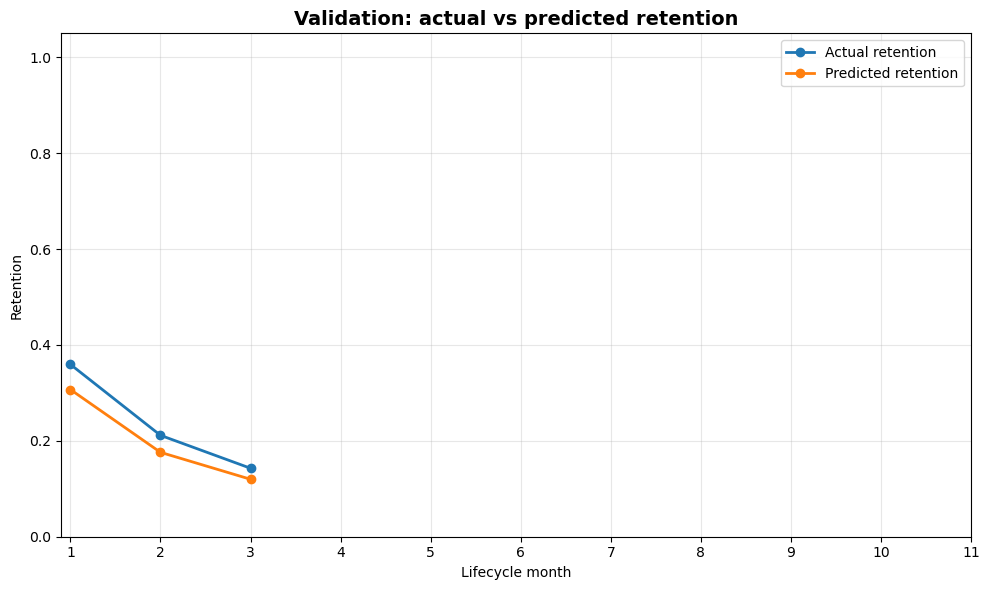


Calibration table:


,prob_bucket,predicted_prob,actual_rate,rows
0,"(0.0726, 0.127]",0.114337,0.143818,3567
1,"(0.127, 0.182]",0.177316,0.206222,2861
2,"(0.182, 0.189]",0.189160,0.225311,1367
3,"(0.189, 0.247]",0.244901,0.299902,6102
4,"(0.247, 0.285]",0.275298,0.336128,3817
5,"(0.285, 0.317]",0.314796,0.373232,2757
6,"(0.317, 0.327]",0.327323,0.376742,2081
7,"(0.327, 0.337]",0.336738,0.386247,1367
8,"(0.337, 0.381]",0.367749,0.421674,1947


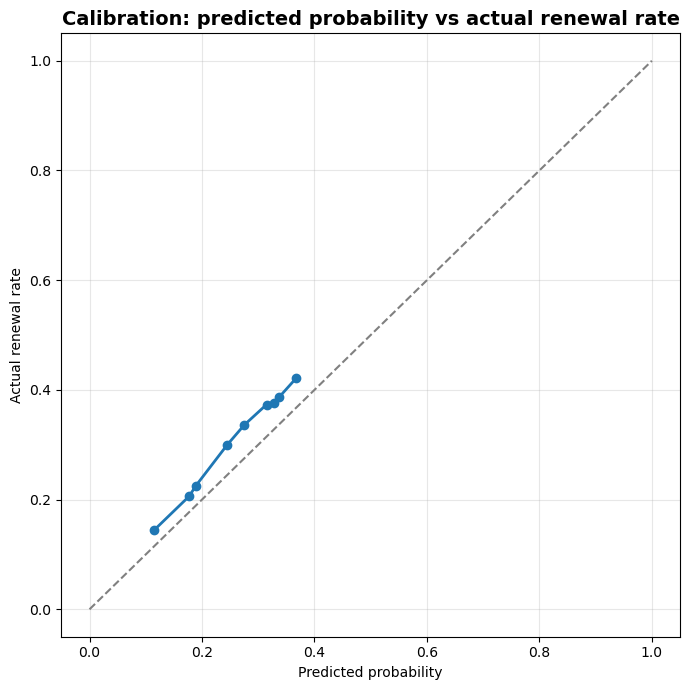

In [17]:
# ============================================================
# VALIDATION: CALIBRATION AND RETENTION QUALITY
# ============================================================
print("=" * 60)
print("20. VALIDATION: CALIBRATION AND RETENTION QUALITY")
print("=" * 60)

# -------------------------------
# Check quality at cohort x lifecycle_month level
# -------------------------------
validation_by_month = val_df.groupby(['cohort_month', 'lifecycle_month']).agg(
    actual_retention=('renewed', 'mean'),
    predicted_retention=('predicted_renewal_prob', 'mean'),
    users=('user_id', 'nunique')
).reset_index()

mae_retention = mean_absolute_error(
    validation_by_month['actual_retention'],
    validation_by_month['predicted_retention']
)

rmse_retention = np.sqrt(mean_squared_error(
    validation_by_month['actual_retention'],
    validation_by_month['predicted_retention']
))

print(f"MAE retention at cohort x lifecycle_month level: {mae_retention:.4f}")
print(f"RMSE retention at cohort x lifecycle_month level: {rmse_retention:.4f}")

display(validation_by_month.head(20))

# -------------------------------
# Plot actual vs predicted retention
# -------------------------------
validation_curve = validation_by_month.groupby('lifecycle_month').agg(
    actual_retention=('actual_retention', 'mean'),
    predicted_retention=('predicted_retention', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(
    validation_curve['lifecycle_month'],
    validation_curve['actual_retention'],
    marker='o',
    linewidth=2,
    label='Actual retention'
)
plt.plot(
    validation_curve['lifecycle_month'],
    validation_curve['predicted_retention'],
    marker='o',
    linewidth=2,
    label='Predicted retention'
)

plt.title('Validation: actual vs predicted retention', fontsize=14, fontweight='bold')
plt.xlabel('Lifecycle month')
plt.ylabel('Retention')
plt.ylim(0, 1.05)
plt.xticks(range(1, FORECAST_HORIZON_MONTHS))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Calibration by probability buckets
# -------------------------------
val_df['prob_bucket'] = pd.qcut(
    val_df['predicted_renewal_prob'],
    q=10,
    duplicates='drop'
)

calibration_df = val_df.groupby('prob_bucket').agg(
    predicted_prob=('predicted_renewal_prob', 'mean'),
    actual_rate=('renewed', 'mean'),
    rows=('user_id', 'count')
).reset_index()

print("\nCalibration table:")
display(calibration_df)

plt.figure(figsize=(7, 7))
plt.plot(
    calibration_df['predicted_prob'],
    calibration_df['actual_rate'],
    marker='o',
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('Calibration: predicted probability vs actual renewal rate', fontsize=14, fontweight='bold')
plt.xlabel('Predicted probability')
plt.ylabel('Actual renewal rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# REFIT FINAL MODEL ON ALL OBSERVABLE DATA
# ============================================================
print("=" * 60)
print("REFIT FINAL MODEL ON ALL OBSERVABLE DATA")
print("=" * 60)

X_all = retention_model_df[feature_cols].copy()
y_all = retention_model_df[target_col].copy()

final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X_all)

final_retention_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    C=1.0
)

final_retention_model.fit(X_all_scaled, y_all)

print("The final model is trained on all observed data")
print(f"Number of training rows: {len(retention_model_df)}")
print(f"Average renewal rate: {y_all.mean():.2%}")

REFIT FINAL MODEL ON ALL OBSERVABLE DATA
The final model is trained on all observed data
Number of training rows: 515870
Average renewal rate: 14.14%


In [19]:
# ============================================================
# PREPARE FULL PANEL FOR LTV PREDICTION
# ============================================================

print("=" * 60)
print("PREPARE FULL PANEL FOR LTV PREDICTION")
print("=" * 60)

ltv_panel_df = model_panel_df.copy()

# -------------------------------
# Create same features as in training
# -------------------------------
ltv_panel_df['cohort_month_num'] = ltv_panel_df['cohort_month'].dt.month
ltv_panel_df['expected_calendar_month_num'] = ltv_panel_df['expected_renewal_month'].dt.month

ltv_panel_df['gender_male'] = (ltv_panel_df['gender'] == 'male').astype(int)
ltv_panel_df['gender_female'] = (ltv_panel_df['gender'] == 'female').astype(int)

ltv_panel_df['geo_tier1'] = (ltv_panel_df['geo'] == 'tier-1').astype(int)
ltv_panel_df['geo_tier2'] = (ltv_panel_df['geo'] == 'tier-2').astype(int)

for month in range(1, FORECAST_HORIZON_MONTHS):
    ltv_panel_df[f'lifecycle_month_{month}'] = (
        ltv_panel_df['lifecycle_month'] == month
    ).astype(int)

for month in range(1, 13):
    ltv_panel_df[f'cohort_start_month_{month}'] = (
        ltv_panel_df['cohort_month_num'] == month
    ).astype(int)

for month in range(1, 13):
    ltv_panel_df[f'renewal_calendar_month_{month}'] = (
        ltv_panel_df['expected_calendar_month_num'] == month
    ).astype(int)

for month in range(1, FORECAST_HORIZON_MONTHS):
    ltv_panel_df[f'geo_tier1_x_month_{month}'] = (
        ltv_panel_df['geo_tier1'] * ltv_panel_df[f'lifecycle_month_{month}']
    )
    ltv_panel_df[f'geo_tier2_x_month_{month}'] = (
        ltv_panel_df['geo_tier2'] * ltv_panel_df[f'lifecycle_month_{month}']
    )
    ltv_panel_df[f'gender_male_x_month_{month}'] = (
        ltv_panel_df['gender_male'] * ltv_panel_df[f'lifecycle_month_{month}']
    )
    ltv_panel_df[f'gender_female_x_month_{month}'] = (
        ltv_panel_df['gender_female'] * ltv_panel_df[f'lifecycle_month_{month}']
    )

# Check that all required features are present
missing_features = [col for col in feature_cols if col not in ltv_panel_df.columns]

if len(missing_features) > 0:
    print("Missing features:")
    print(missing_features)
else:
    print("All features for LTV prediction are prepared")

display(ltv_panel_df.head(12))

PREPARE FULL PANEL FOR LTV PREDICTION
All features for LTV prediction are prepared


,user_id,cohort_month,lifecycle_month,gender,geo,revenue,renewed,expected_renewal_month,is_observable,cohort_month_num,...,gender_male_x_month_9,gender_female_x_month_9,geo_tier1_x_month_10,geo_tier2_x_month_10,gender_male_x_month_10,gender_female_x_month_10,geo_tier1_x_month_11,geo_tier2_x_month_11,gender_male_x_month_11,gender_female_x_month_11
0,user_1,2024-01,0,male,tier-1,29.99,1,2024-01,1,1,...,0,0,0,0,0,0,0,0,0,0
1,user_1,2024-01,1,male,tier-1,0.00,0,2024-02,1,1,...,0,0,0,0,0,0,0,0,0,0
2,user_1,2024-01,2,male,tier-1,0.00,0,2024-03,1,1,...,0,0,0,0,0,0,0,0,0,0
3,user_1,2024-01,3,male,tier-1,0.00,0,2024-04,1,1,...,0,0,0,0,0,0,0,0,0,0
4,user_1,2024-01,4,male,tier-1,0.00,0,2024-05,1,1,...,0,0,0,0,0,0,0,0,0,0
5,user_1,2024-01,5,male,tier-1,0.00,0,2024-06,1,1,...,0,0,0,0,0,0,0,0,0,0
6,user_1,2024-01,6,male,tier-1,0.00,0,2024-07,1,1,...,0,0,0,0,0,0,0,0,0,0
7,user_1,2024-01,7,male,tier-1,0.00,0,2024-08,1,1,...,0,0,0,0,0,0,0,0,0,0
8,user_1,2024-01,8,male,tier-1,0.00,0,2024-09,1,1,...,0,0,0,0,0,0,0,0,0,0
9,user_1,2024-01,9,male,tier-1,0.00,0,2024-10,1,1,...,1,0,0,0,0,0,0,0,0,0


In [20]:
# ============================================================
# PREDICT USER-LEVEL EXPECTED LTV
# ============================================================
print("=" * 60)
print("PREDICT USER-LEVEL EXPECTED LTV")
print("=" * 60)

# -------------------------------
# For month_0, payment probability = 1,
# because it's the initial purchase.
#
# For lifecycle_month >= 1:
# - if month is already observed, use actual renewed;
# - if month is not yet observed, use model prediction.
#
# This is hybrid LTV:
# observed actuals + predicted future.
# -------------------------------

ltv_panel_df['model_predicted_renewal_prob'] = np.nan

prediction_mask = ltv_panel_df['lifecycle_month'] >= 1

X_ltv = ltv_panel_df.loc[prediction_mask, feature_cols].copy()
X_ltv_scaled = final_scaler.transform(X_ltv)

ltv_panel_df.loc[prediction_mask, 'model_predicted_renewal_prob'] = (
    final_retention_model.predict_proba(X_ltv_scaled)[:, 1]
)

# -------------------------------
# Expected payment probability
# -------------------------------
ltv_panel_df['expected_payment_prob'] = np.where(
    ltv_panel_df['lifecycle_month'] == 0,
    1.0,
    np.where(
        ltv_panel_df['is_observable'] == 1,
        ltv_panel_df['renewed'],
        ltv_panel_df['model_predicted_renewal_prob']
    )
)

ltv_panel_df['expected_revenue'] = (
    ltv_panel_df['expected_payment_prob'] * MONTHLY_PRICE
)

# Mark separately where it's actual vs predicted
ltv_panel_df['ltv_component_type'] = np.where(
    ltv_panel_df['lifecycle_month'] == 0,
    'actual_initial_purchase',
    np.where(
        ltv_panel_df['is_observable'] == 1,
        'actual_observed_renewal',
        'predicted_future_renewal'
    )
)

print("Example of expected revenue calculation:")
display(
    ltv_panel_df[
        [
            'user_id',
            'cohort_month',
            'lifecycle_month',
            'renewed',
            'is_observable',
            'model_predicted_renewal_prob',
            'expected_payment_prob',
            'expected_revenue',
            'ltv_component_type'
        ]
    ].head(20)
)

PREDICT USER-LEVEL EXPECTED LTV
Example of expected revenue calculation:


,user_id,cohort_month,lifecycle_month,renewed,is_observable,model_predicted_renewal_prob,expected_payment_prob,expected_revenue,ltv_component_type
0,user_1,2024-01,0,1,1,NaN,1.0,29.99,actual_initial_purchase
1,user_1,2024-01,1,0,1,0.431688,0.0,0.00,actual_observed_renewal
2,user_1,2024-01,2,0,1,0.274212,0.0,0.00,actual_observed_renewal
3,user_1,2024-01,3,0,1,0.203286,0.0,0.00,actual_observed_renewal
4,user_1,2024-01,4,0,1,0.160696,0.0,0.00,actual_observed_renewal
5,user_1,2024-01,5,0,1,0.131652,0.0,0.00,actual_observed_renewal
6,user_1,2024-01,6,0,1,0.109241,0.0,0.00,actual_observed_renewal
7,user_1,2024-01,7,0,1,0.095367,0.0,0.00,actual_observed_renewal
8,user_1,2024-01,8,0,1,0.080995,0.0,0.00,actual_observed_renewal
9,user_1,2024-01,9,0,1,0.071547,0.0,0.00,actual_observed_renewal


In [21]:
# ============================================================
# USER-LEVEL LTV
# ============================================================

print("=" * 60)
print("USER-LEVEL LTV")
print("=" * 60)

user_ltv_df = ltv_panel_df.groupby(
    ['user_id', 'cohort_month', 'gender', 'geo']
).agg(
    expected_paid_periods=('expected_payment_prob', 'sum'),
    expected_ltv=('expected_revenue', 'sum'),
    observed_paid_periods=('renewed', 'sum'),
    observed_revenue=('revenue', 'sum'),
    observable_periods=('is_observable', 'sum'),
    predicted_future_revenue=(
        'expected_revenue',
        lambda x: x[ltv_panel_df.loc[x.index, 'ltv_component_type'] == 'predicted_future_renewal'].sum()
    ),
    actual_observed_revenue=(
        'expected_revenue',
        lambda x: x[ltv_panel_df.loc[x.index, 'ltv_component_type'] != 'predicted_future_renewal'].sum()
    )
).reset_index()

print("User-level LTV:")
display(user_ltv_df.head())

print("Description of the expected LTV at the user level:")
display(user_ltv_df['expected_ltv'].describe())

USER-LEVEL LTV
User-level LTV:


,user_id,cohort_month,gender,geo,expected_paid_periods,expected_ltv,observed_paid_periods,observed_revenue,observable_periods,predicted_future_revenue,actual_observed_revenue
0,user_1,2024-01,male,tier-1,1.0,29.99,1,29.99,12,0.0,29.99
1,user_10,2024-01,male,tier-2,3.0,89.97,3,89.97,12,0.0,89.97
2,user_100,2024-01,male,tier-1,1.0,29.99,1,29.99,12,0.0,29.99
3,user_1000,2024-01,male,tier-1,1.0,29.99,1,29.99,12,0.0,29.99
4,user_10000,2024-01,female,tier-1,11.0,329.89,11,329.89,12,0.0,329.89


Description of the expected LTV at the user level:


count    76275.000000
mean        69.440309
std         58.021263
min         29.990000
25%         33.331314
50%         51.786866
75%         81.650160
max        359.880000
Name: expected_ltv, dtype: float64

COHORT-LEVEL LTV
Cohort-level LTV:


,cohort_month,users,avg_expected_ltv,median_expected_ltv,avg_observed_revenue,avg_predicted_future_revenue,avg_actual_observed_revenue,avg_expected_paid_periods,tier1_share,tier2_share,female_share,male_share
0,2024-01,10624,65.820485,29.990000,65.820485,0.000000,65.820485,2.194748,0.480610,0.519390,0.515248,0.484752
1,2024-02,9349,67.470282,29.990000,67.470282,0.000000,67.470282,2.249759,0.596427,0.403573,0.588940,0.411060
2,2024-03,7064,68.907036,32.572512,67.222772,1.684264,67.222772,2.297667,0.519394,0.480606,0.390572,0.609428
3,2024-04,2390,65.470898,33.331314,62.439431,3.031467,62.439431,2.183091,0.545188,0.454812,0.655649,0.344351
4,2024-05,5152,68.535535,35.652259,63.309635,5.225900,63.309635,2.285280,0.619565,0.380435,0.723991,0.276009
5,2024-06,8074,69.337924,37.765149,61.826053,7.511871,61.826053,2.312035,0.725291,0.274709,0.761333,0.238667
6,2024-07,4727,67.896158,40.026179,58.501754,9.394404,58.501754,2.263960,0.670616,0.329384,0.759890,0.240110
7,2024-08,5099,71.887493,43.778946,58.397864,13.489628,58.397864,2.397049,0.727398,0.272602,0.736223,0.263777
8,2024-09,6640,75.257860,56.359664,56.755172,18.502688,56.755172,2.509432,0.771235,0.228765,0.657982,0.342018
9,2024-10,2549,73.107859,52.367304,51.908937,21.198922,51.908937,2.437741,0.692428,0.307572,0.764614,0.235386


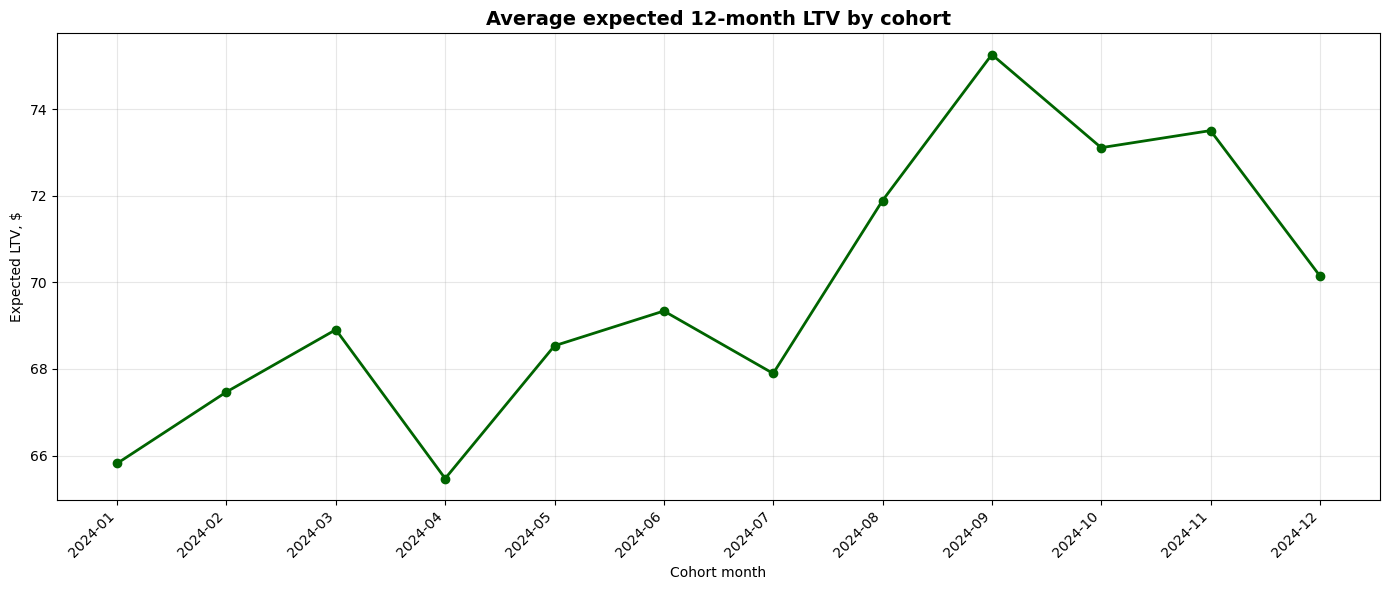

In [22]:
# ============================================================
# COHORT-LEVEL LTV
# ============================================================
print("=" * 60)
print("COHORT-LEVEL LTV")
print("=" * 60)

cohort_ltv_df = user_ltv_df.groupby('cohort_month').agg(
    users=('user_id', 'nunique'),
    avg_expected_ltv=('expected_ltv', 'mean'),
    median_expected_ltv=('expected_ltv', 'median'),
    avg_observed_revenue=('observed_revenue', 'mean'),
    avg_predicted_future_revenue=('predicted_future_revenue', 'mean'),
    avg_actual_observed_revenue=('actual_observed_revenue', 'mean'),
    avg_expected_paid_periods=('expected_paid_periods', 'mean'),
    tier1_share=('geo', lambda x: (x == 'tier-1').mean()),
    tier2_share=('geo', lambda x: (x == 'tier-2').mean()),
    female_share=('gender', lambda x: (x == 'female').mean()),
    male_share=('gender', lambda x: (x == 'male').mean())
).reset_index()

cohort_ltv_df = cohort_ltv_df.sort_values('cohort_month').reset_index(drop=True)

print("Cohort-level LTV:")
display(cohort_ltv_df)

plt.figure(figsize=(14, 6))
plt.plot(
    cohort_ltv_df['cohort_month'].astype(str),
    cohort_ltv_df['avg_expected_ltv'],
    marker='o',
    linewidth=2,
    color='darkgreen'
)

plt.title('Average expected 12-month LTV by cohort', fontsize=14, fontweight='bold')
plt.xlabel('Cohort month')
plt.ylabel('Expected LTV, $')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# JANUARY 2024 VS DECEMBER 2024 COMPARISON
# ============================================================

print("=" * 60)
print("JANUARY 2024 VS DECEMBER 2024 COMPARISON")
print("=" * 60)

target_cohorts_ltv = cohort_ltv_df[
    cohort_ltv_df['cohort_month'].isin([JAN_2024, DEC_2024])
].copy()

print("Comparison of cohorts:")
display(target_cohorts_ltv)

jan_ltv = target_cohorts_ltv.loc[
    target_cohorts_ltv['cohort_month'] == JAN_2024,
    'avg_expected_ltv'
].iloc[0]

dec_ltv = target_cohorts_ltv.loc[
    target_cohorts_ltv['cohort_month'] == DEC_2024,
    'avg_expected_ltv'
].iloc[0]

abs_diff = dec_ltv - jan_ltv
rel_diff = dec_ltv / jan_ltv - 1

print(f"January 2024 average expected 12-month LTV: ${jan_ltv:.2f}")
print(f"December 2024 average expected 12-month LTV: ${dec_ltv:.2f}")
print(f"Difference Dec 2024 - Jan 2024: ${abs_diff:.2f}")
print(f"Relative difference: {rel_diff:.2%}")

JANUARY 2024 VS DECEMBER 2024 COMPARISON
Comparison of cohorts:


,cohort_month,users,avg_expected_ltv,median_expected_ltv,avg_observed_revenue,avg_predicted_future_revenue,avg_actual_observed_revenue,avg_expected_paid_periods,tier1_share,tier2_share,female_share,male_share
0,2024-01,10624,65.820485,29.990000,65.820485,0.000000,65.820485,2.194748,0.480610,0.519390,0.515248,0.484752
11,2024-12,10995,70.148614,67.525846,40.245789,29.902825,40.245789,2.339067,0.309868,0.690132,0.687767,0.312233


January 2024 average expected 12-month LTV: $65.82
December 2024 average expected 12-month LTV: $70.15
Difference Dec 2024 - Jan 2024: $4.33
Relative difference: 6.58%


JANUARY 2024 VS DECEMBER 2024: LTV CURVES


,cohort_month,lifecycle_month,avg_expected_revenue,avg_expected_payment_prob,actual_retention,observable_share,cumulative_expected_ltv
0,2024-01,0,29.990000,1.000000,1.000000,1.0,29.990000
1,2024-01,1,10.992193,0.366529,0.366529,1.0,40.982193
2,2024-01,2,6.198987,0.206702,0.206702,1.0,47.181180
3,2024-01,3,4.189115,0.139684,0.139684,1.0,51.370296
4,2024-01,4,3.172888,0.105798,0.105798,1.0,54.543183
5,2024-01,5,2.520809,0.084055,0.084055,1.0,57.063992
6,2024-01,6,2.038101,0.067959,0.067959,1.0,59.102092
7,2024-01,7,1.733232,0.057794,0.057794,1.0,60.835325
8,2024-01,8,1.473530,0.049134,0.049134,1.0,62.308854
9,2024-01,9,1.304159,0.043486,0.043486,1.0,63.613013


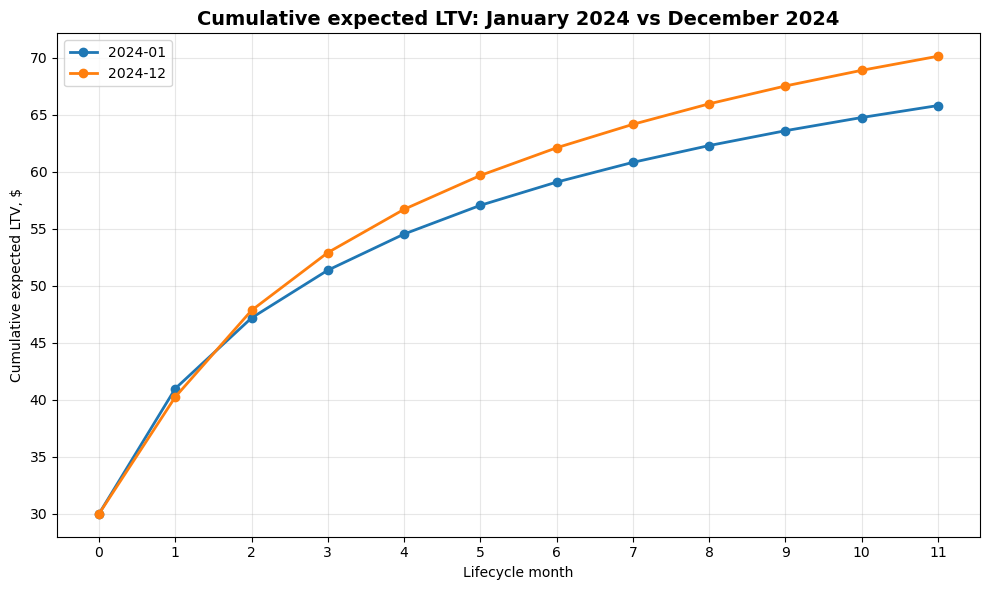

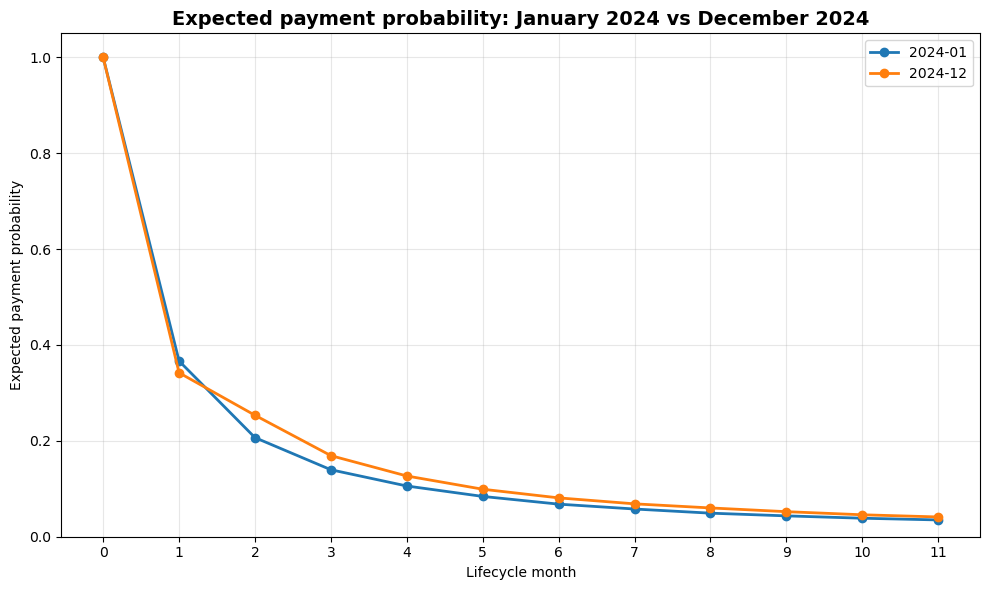

In [35]:
# ============================================================
# JANUARY 2024 VS DECEMBER 2024: LTV CURVES
# ============================================================
print("=" * 60)
print("JANUARY 2024 VS DECEMBER 2024: LTV CURVES")
print("=" * 60)

# -------------------------------
# Build monthly LTV curve
# -------------------------------
ltv_curve_df = ltv_panel_df.groupby(
    ['cohort_month', 'lifecycle_month']
).agg(
    avg_expected_revenue=('expected_revenue', 'mean'),
    avg_expected_payment_prob=('expected_payment_prob', 'mean'),
    actual_retention=('renewed', 'mean'),
    observable_share=('is_observable', 'mean')
).reset_index()

ltv_curve_df = ltv_curve_df.sort_values(['cohort_month', 'lifecycle_month'])

ltv_curve_df['cumulative_expected_ltv'] = (
    ltv_curve_df
    .groupby('cohort_month')['avg_expected_revenue']
    .cumsum()
)

target_ltv_curve = ltv_curve_df[
    ltv_curve_df['cohort_month'].isin([JAN_2024, DEC_2024])
].copy()

display(target_ltv_curve)

# -------------------------------
# Plot cumulative expected LTV
# -------------------------------
plt.figure(figsize=(10, 6))

for cohort in [JAN_2024, DEC_2024]:
    data = target_ltv_curve[target_ltv_curve['cohort_month'] == cohort]
    plt.plot(
        data['lifecycle_month'],
        data['cumulative_expected_ltv'],
        marker='o',
        linewidth=2,
        label=str(cohort)
    )

plt.title('Cumulative expected LTV: January 2024 vs December 2024', fontsize=14, fontweight='bold')
plt.xlabel('Lifecycle month')
plt.ylabel('Cumulative expected LTV, $')
plt.xticks(range(FORECAST_HORIZON_MONTHS))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Plot expected payment probability
# -------------------------------
plt.figure(figsize=(10, 6))

for cohort in [JAN_2024, DEC_2024]:
    data = target_ltv_curve[target_ltv_curve['cohort_month'] == cohort]
    plt.plot(
        data['lifecycle_month'],
        data['avg_expected_payment_prob'],
        marker='o',
        linewidth=2,
        label=str(cohort)
    )

plt.title('Expected payment probability: January 2024 vs December 2024', fontsize=14, fontweight='bold')
plt.xlabel('Lifecycle month')
plt.ylabel('Expected payment probability')
plt.ylim(0, 1.05)
plt.xticks(range(FORECAST_HORIZON_MONTHS))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

LTV DIFFERENCE DECOMPOSITION BY LIFECYCLE MONTH


,lifecycle_month,jan_expected_revenue,jan_payment_prob,dec_expected_revenue,dec_payment_prob,revenue_diff_dec_minus_jan,payment_prob_diff_dec_minus_jan
0,0,29.990000,1.000000,29.990000,1.000000,-3.552714e-15,0.000000
1,1,10.992193,0.366529,10.255789,0.341974,-7.364042e-01,-0.024555
2,2,6.198987,0.206702,7.597200,0.253324,1.398213e+00,0.046623
3,3,4.189115,0.139684,5.072015,0.169124,8.828998e-01,0.029440
4,4,3.172888,0.105798,3.799353,0.126687,6.264653e-01,0.020889
5,5,2.520809,0.084055,2.970582,0.099052,4.497732e-01,0.014997
6,6,2.038101,0.067959,2.429936,0.081025,3.918356e-01,0.013066
7,7,1.733232,0.057794,2.056769,0.068582,3.235365e-01,0.010788
8,8,1.473530,0.049134,1.800716,0.060044,3.271863e-01,0.010910
9,9,1.304159,0.043486,1.567038,0.052252,2.628799e-01,0.008766


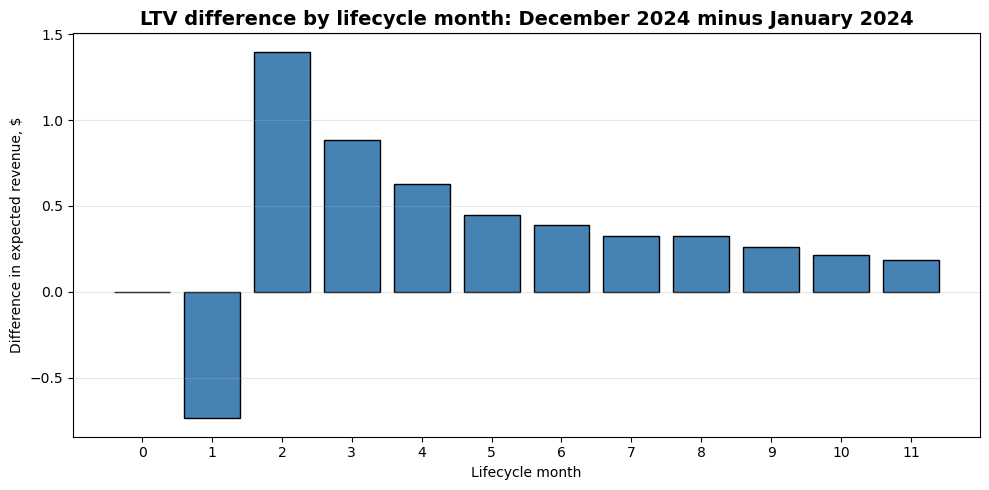

In [36]:
# ============================================================
# LTV DIFFERENCE DECOMPOSITION BY LIFECYCLE MONTH
# ============================================================

print("=" * 60)
print("LTV DIFFERENCE DECOMPOSITION BY LIFECYCLE MONTH")
print("=" * 60)

jan_curve = target_ltv_curve[
    target_ltv_curve['cohort_month'] == JAN_2024
][['lifecycle_month', 'avg_expected_revenue', 'avg_expected_payment_prob']].rename(
    columns={
        'avg_expected_revenue': 'jan_expected_revenue',
        'avg_expected_payment_prob': 'jan_payment_prob'
    }
)

dec_curve = target_ltv_curve[
    target_ltv_curve['cohort_month'] == DEC_2024
][['lifecycle_month', 'avg_expected_revenue', 'avg_expected_payment_prob']].rename(
    columns={
        'avg_expected_revenue': 'dec_expected_revenue',
        'avg_expected_payment_prob': 'dec_payment_prob'
    }
)

ltv_diff_by_month = jan_curve.merge(
    dec_curve,
    on='lifecycle_month',
    how='outer'
)

ltv_diff_by_month['revenue_diff_dec_minus_jan'] = (
    ltv_diff_by_month['dec_expected_revenue'] -
    ltv_diff_by_month['jan_expected_revenue']
)

ltv_diff_by_month['payment_prob_diff_dec_minus_jan'] = (
    ltv_diff_by_month['dec_payment_prob'] -
    ltv_diff_by_month['jan_payment_prob']
)

display(ltv_diff_by_month)

plt.figure(figsize=(10, 5))
plt.bar(
    ltv_diff_by_month['lifecycle_month'],
    ltv_diff_by_month['revenue_diff_dec_minus_jan'],
    color='steelblue',
    edgecolor='black'
)

plt.title('LTV difference by lifecycle month: December 2024 minus January 2024', fontsize=14, fontweight='bold')
plt.xlabel('Lifecycle month')
plt.ylabel('Difference in expected revenue, $')
plt.xticks(range(FORECAST_HORIZON_MONTHS))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

SEGMENT MIX COMPARISON: JANUARY 2024 VS DECEMBER 2024
Segment mix:


,cohort_month,geo,gender,users,share,segment
0,2024-01,tier-1,female,2632,0.247741,tier-1 / female
1,2024-01,tier-1,male,2474,0.232869,tier-1 / male
2,2024-01,tier-2,female,2842,0.267508,tier-2 / female
3,2024-01,tier-2,male,2676,0.251883,tier-2 / male
4,2024-12,tier-1,female,2375,0.216007,tier-1 / female
5,2024-12,tier-1,male,1032,0.093861,tier-1 / male
6,2024-12,tier-2,female,5187,0.471760,tier-2 / female
7,2024-12,tier-2,male,2401,0.218372,tier-2 / male


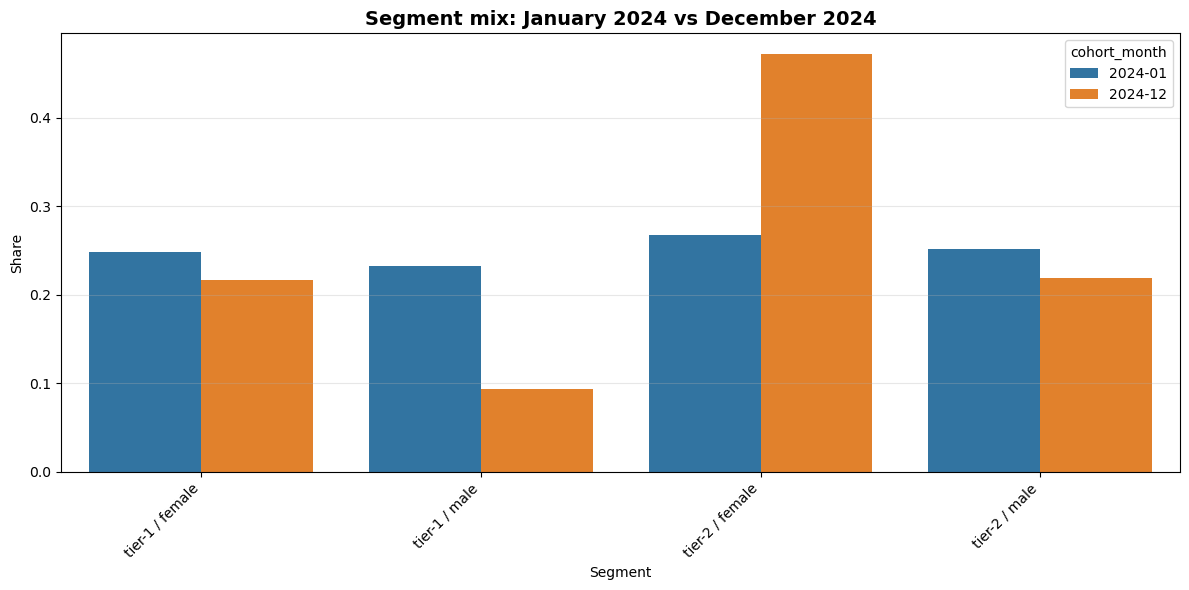

In [37]:
# ============================================================
# SEGMENT MIX COMPARISON: JANUARY 2024 VS DECEMBER 2024
# ============================================================

print("=" * 60)
print("SEGMENT MIX COMPARISON: JANUARY 2024 VS DECEMBER 2024")
print("=" * 60)

segment_mix_df = users_df.copy()

segment_mix_df['subscription_start_date'] = pd.to_datetime(
    segment_mix_df['subscription_start_date'],
    errors='coerce'
)

segment_mix_df['cohort_month'] = segment_mix_df['subscription_start_date'].dt.to_period('M')

segment_mix_df = segment_mix_df[
    segment_mix_df['cohort_month'].isin([JAN_2024, DEC_2024])
].copy()

segment_mix = segment_mix_df.groupby(
    ['cohort_month', 'geo', 'gender']
).agg(
    users=('user_id', 'nunique')
).reset_index()

segment_mix['share'] = (
    segment_mix['users'] /
    segment_mix.groupby('cohort_month')['users'].transform('sum')
)

segment_mix['segment'] = segment_mix['geo'] + ' / ' + segment_mix['gender']

print("Segment mix:")
display(segment_mix)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=segment_mix,
    x='segment',
    y='share',
    hue=segment_mix['cohort_month'].astype(str)
)

plt.title('Segment mix: January 2024 vs December 2024', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Share')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

BOOTSTRAP CONFIDENCE INTERVALS FOR COHORT LTV
Bootstrap confidence intervals:


,cohort_month,users,mean_ltv,ci_lower_95,ci_upper_95
0,2024-01,10624,65.820485,64.355071,67.203824
1,2024-12,10995,70.148614,69.831566,70.496844


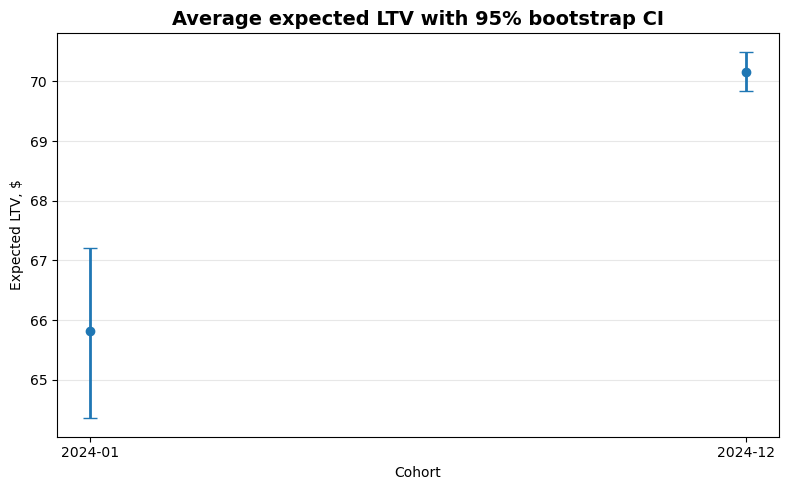

In [38]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVALS FOR COHORT LTV
# ============================================================

print("=" * 60)
print("BOOTSTRAP CONFIDENCE INTERVALS FOR COHORT LTV")
print("=" * 60)

def bootstrap_mean_ci(data, value_col, n_bootstrap=1000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    values = data[value_col].dropna().values

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    n = len(values)
    boot_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(values, size=n, replace=True)
        boot_means.append(sample.mean())

    alpha = 1 - ci

    mean_value = values.mean()
    lower = np.quantile(boot_means, alpha / 2)
    upper = np.quantile(boot_means, 1 - alpha / 2)

    return mean_value, lower, upper


bootstrap_results = []

for cohort in [JAN_2024, DEC_2024]:
    data = user_ltv_df[user_ltv_df['cohort_month'] == cohort].copy()

    mean_ltv, lower_ci, upper_ci = bootstrap_mean_ci(
        data=data,
        value_col='expected_ltv',
        n_bootstrap=1000,
        ci=0.95,
        random_state=RANDOM_STATE
    )

    bootstrap_results.append({
        'cohort_month': cohort,
        'users': data['user_id'].nunique(),
        'mean_ltv': mean_ltv,
        'ci_lower_95': lower_ci,
        'ci_upper_95': upper_ci
    })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

print("Bootstrap confidence intervals:")
display(bootstrap_results_df)

plt.figure(figsize=(8, 5))

plt.errorbar(
    bootstrap_results_df['cohort_month'].astype(str),
    bootstrap_results_df['mean_ltv'],
    yerr=[
        bootstrap_results_df['mean_ltv'] - bootstrap_results_df['ci_lower_95'],
        bootstrap_results_df['ci_upper_95'] - bootstrap_results_df['mean_ltv']
    ],
    fmt='o',
    capsize=5,
    linewidth=2
)

plt.title('Average expected LTV with 95% bootstrap CI', fontsize=14, fontweight='bold')
plt.xlabel('Cohort')
plt.ylabel('Expected LTV, $')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print("=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)

final_summary_table = target_cohorts_ltv.merge(
    bootstrap_results_df[['cohort_month', 'ci_lower_95', 'ci_upper_95']],
    on='cohort_month',
    how='left'
)

final_summary_table['cohort_month'] = final_summary_table['cohort_month'].astype(str)

final_summary_table = final_summary_table[
    [
        'cohort_month',
        'users',
        'avg_expected_ltv',
        'median_expected_ltv',
        'ci_lower_95',
        'ci_upper_95',
        'avg_observed_revenue',
        'avg_predicted_future_revenue',
        'avg_actual_observed_revenue',
        'avg_expected_paid_periods',
        'tier1_share',
        'tier2_share',
        'female_share',
        'male_share'
    ]
]

display(final_summary_table)

print("\n" + "=" * 60)
print("KEY OUTPUT")
print("=" * 60)

print(f"January 2024 average expected 12-month LTV: ${jan_ltv:.2f}")
print(f"December 2024 average expected 12-month LTV: ${dec_ltv:.2f}")
print(f"Difference Dec 2024 - Jan 2024: ${abs_diff:.2f}")
print(f"Relative difference: {rel_diff:.2%}")

if dec_ltv > jan_ltv:
    print("\nDecember 2024 cohort has higher expected LTV than January 2024 cohort.")
else:
    print("\nDecember 2024 cohort has lower expected LTV than January 2024 cohort.")

FINAL SUMMARY TABLE


,cohort_month,users,avg_expected_ltv,median_expected_ltv,ci_lower_95,ci_upper_95,avg_observed_revenue,avg_predicted_future_revenue,avg_actual_observed_revenue,avg_expected_paid_periods,tier1_share,tier2_share,female_share,male_share
0,2024-01,10624,65.820485,29.990000,64.355071,67.203824,65.820485,0.000000,65.820485,2.194748,0.480610,0.519390,0.515248,0.484752
1,2024-12,10995,70.148614,67.525846,69.831566,70.496844,40.245789,29.902825,40.245789,2.339067,0.309868,0.690132,0.687767,0.312233



KEY OUTPUT
January 2024 average expected 12-month LTV: $65.82
December 2024 average expected 12-month LTV: $70.15
Difference Dec 2024 - Jan 2024: $4.33
Relative difference: 6.58%

December 2024 cohort has higher expected LTV than January 2024 cohort.


MODEL COEFFICIENTS INTERPRETATION
Top positive coefficients:


,feature,coefficient
5,lifecycle_month_1,0.153765
43,gender_female_x_month_1,0.121655
41,geo_tier2_x_month_1,0.104839
40,geo_tier1_x_month_1,0.104622
3,geo_tier1,0.099736
42,gender_male_x_month_1,0.084515
6,lifecycle_month_2,0.061186
1,gender_male,0.055705
44,geo_tier1_x_month_2,0.055673
46,gender_male_x_month_2,0.043453


Top negative coefficients:


,feature,coefficient
11,lifecycle_month_7,-0.047933
16,cohort_start_month_1,-0.048148
13,lifecycle_month_9,-0.048620
12,lifecycle_month_8,-0.048657
83,gender_female_x_month_11,-0.048849
14,lifecycle_month_10,-0.049713
63,gender_female_x_month_6,-0.049851
79,gender_female_x_month_10,-0.051614
75,gender_female_x_month_9,-0.051616
71,gender_female_x_month_8,-0.051790


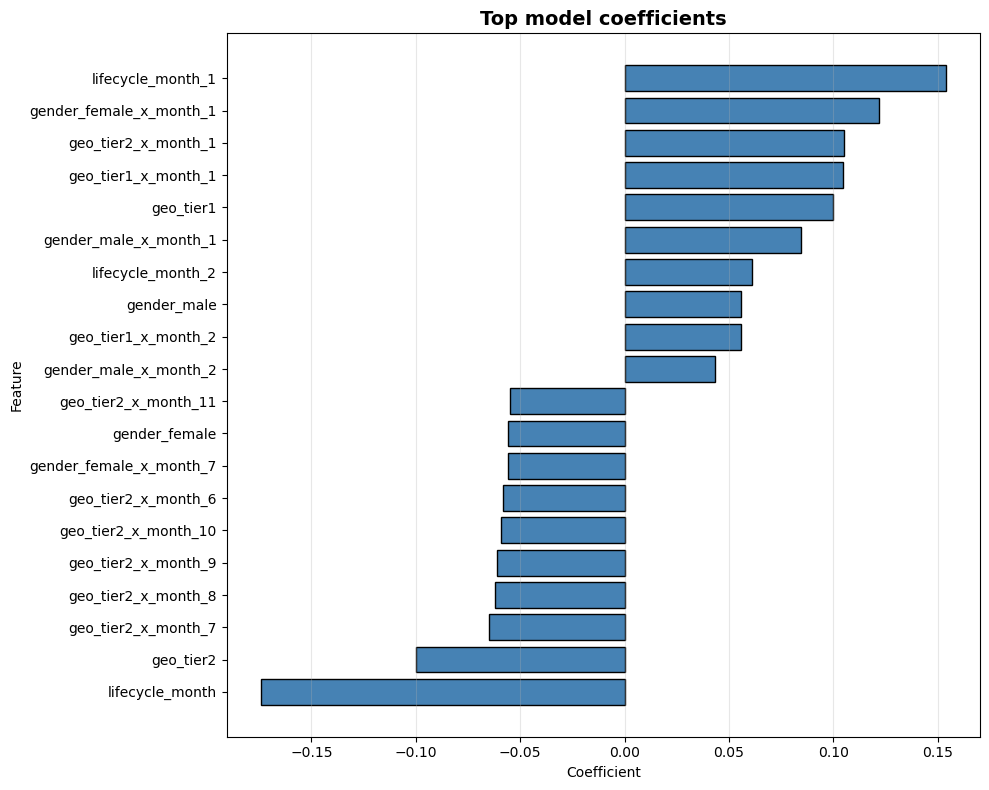

In [43]:
# ============================================================
# MODEL COEFFICIENTS INTERPRETATION
# ============================================================

print("=" * 60)
print("MODEL COEFFICIENTS INTERPRETATION")
print("=" * 60)

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': final_retention_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top positive coefficients:")
display(coef_df.head(20))

print("Top negative coefficients:")
display(coef_df.tail(20))

plt.figure(figsize=(10, 8))

top_coef_plot = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
]).sort_values('coefficient')

plt.barh(
    top_coef_plot['feature'],
    top_coef_plot['coefficient'],
    color='steelblue',
    edgecolor='black'
)

plt.title('Top model coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# FINAL REPORT
# ============================================================

print("=" * 60)
print("FINAL REPORT")
print("=" * 60)

report_text = f"""
METHODOLOGY

The raw renewal events were transformed into a user-month panel, where each row represents one user
and one lifecycle month from month 0 to month {FORECAST_HORIZON_MONTHS - 1}.

The 12-month LTV horizon was defined as the first {FORECAST_HORIZON_MONTHS} billing periods:
renewal_number 0 through renewal_number {FORECAST_HORIZON_MONTHS - 1}.
The initial purchase, renewal_number = 0, is treated as already paid for every user in users_info.

A key methodological point is the treatment of censored observations.
If a lifecycle month is later than the maximum observed renewal month in the dataset, then the absence
of a renewal event should not be interpreted as churn. For this reason, the analysis separates observable
and non-observable lifecycle months.

The final LTV estimate uses a hybrid approach:
1. For observable lifecycle months, actual renewal behavior is used.
2. For non-observable future lifecycle months, renewal probability is predicted using a discrete-time
   retention model.
3. Expected LTV is calculated as the sum of expected monthly revenues over the 12-month horizon.

MODEL

The discrete-time retention model is a logistic regression trained on observable user-month rows
with lifecycle_month >= 1. The target variable is whether the user renewed in that lifecycle month.

The model includes the following features:
- lifecycle month;
- gender;
- geo;
- subscription start month;
- expected calendar month of renewal;
- interactions between lifecycle month and user segments.

RESULTS

January 2024 average expected 12-month LTV: ${jan_ltv:.2f}
December 2024 average expected 12-month LTV: ${dec_ltv:.2f}

The absolute difference between December 2024 and January 2024 is ${abs_diff:.2f}.
The relative difference is {rel_diff:.2%}.

LIMITATIONS

The model assumes a fixed monthly price of ${MONTHLY_PRICE:.2f}.
It does not account for acquisition channel, marketing campaign, discounts, refunds, plan changes,
or user engagement behavior inside the product.

The December 2024 cohort may have a larger forecasted component if the full 12-month horizon
is not yet observable in the data. Therefore, its LTV estimate has higher uncertainty than older,
more mature cohorts.
"""

print(report_text)

FINAL REPORT

METHODOLOGY

The raw renewal events were transformed into a user-month panel, where each row represents one user
and one lifecycle month from month 0 to month 11.

The 12-month LTV horizon was defined as the first 12 billing periods:
renewal_number 0 through renewal_number 11.
The initial purchase, renewal_number = 0, is treated as already paid for every user in users_info.

A key methodological point is the treatment of censored observations.
If a lifecycle month is later than the maximum observed renewal month in the dataset, then the absence
of a renewal event should not be interpreted as churn. For this reason, the analysis separates observable
and non-observable lifecycle months.

The final LTV estimate uses a hybrid approach:
1. For observable lifecycle months, actual renewal behavior is used.
2. For non-observable future lifecycle months, renewal probability is predicted using a discrete-time
   retention model.
3. Expected LTV is calculated as the sum of expected 